# Forecasting Assignment: U.S. Lodging Prices (CPI)

**Student:** Beatrice Infurna  

**Course:** Timeseries Forecasting

**Professor:** Filip Van den Bossche  

**Date:** April 2026

### Dataset Description

The purpose of this notebook is to analyze and forecast the Consumer Price Index (CPI) for Lodging Away from Home in the United States (CUUR0000SEHB series) published monthly by the United States Bureau of Labor Statistics (BLS). The CPI measures the price change of hotel and lodging services that are experienced by urban consumers.

**Source**: United States Bureau of Labor Statistics, obtained through FRED (Federal Reserve Economic Data).
Link: https://fred.stlouisfed.org/series/CUUR0000SEHB

**Why this data?**
Travel related lodging pricing represents a point where the travel industry and hospitality intersect with consumer spending.
It has:
- Clearly identifiable monthly seasonal fluctuations as a result of summertime travel peaks (June-August) and winter lows.
- An overall positive trend over time due to general inflation and increased travel demand.
- Around 28 years of data
- Three major economic events: The 2001 recession; the 2008 financial crisis; and the significant decline caused by the COVID-19 pandemic in 2020. Followed by the recent inflationary growth in 2021 – 2023.

All of these characteristics make it suitable for both ETS and ARIMA forecasting methodologies to be applied and compared ( and respect the requirements asked by the assignment)

**note**: this dataset was run on google colab

## 1.Setup and first Data exploration

### 1.1 Environment Setup

The following cells install and import all required packages.

In [56]:
!pip install statsforecast
!pip install neuralforecast

In [57]:
!pip install pmdarima

In [58]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox_normmax
from functools import partial

# Statsmodels
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from matplotlib.ticker import MaxNLocator

# StatsForecast
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoETS, AutoARIMA, ARIMA,
    SeasonalNaive, Naive, HistoricAverage
)

# For differencing tests
from pmdarima.arima import ndiffs, nsdiffs

# ML models
from sklearn.ensemble import GradientBoostingRegressor

# Plot settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("All packages loaded successfully!")

All packages loaded successfully!


In [59]:
#  Helper Functions (created similarly to forecasting_initiate.py, used in the in class exercises)

def prepare_series(df, date_col, y_col, id_value='Series 1', regressors=None):
    """Prepare DataFrame for StatsForecast with optional regressors."""
    df = df.copy()
    df = df.rename(columns={date_col: 'ds', y_col: 'y'})
    df['ds'] = pd.to_datetime(df['ds'])
    df['unique_id'] = id_value

    # Select columns to keep
    cols = ['unique_id', 'ds', 'y']
    if regressors:
        cols.extend(regressors)

    df = df[cols].sort_values('ds').reset_index(drop=True)
    return df

def plot_series(train, forecasts=None, xlabel='Date', ylabel='Value', title='Time Series'):
    """Plot time series with optional forecasts."""
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train['ds'], train['y'], color='steelblue', linewidth=1, label='Historical')

    if forecasts is not None:
        if 'y' in forecasts.columns:
            ax.plot(forecasts['ds'], forecasts['y'], color='black', linewidth=1.5, label='Actual')

        colors = plt.cm.Set2.colors
        forecast_cols = [c for c in forecasts.columns if c not in ['ds', 'y', 'unique_id', 'index']
                        and 'lo' not in c.lower() and 'hi' not in c.lower()]
        for i, col in enumerate(forecast_cols):
            ax.plot(forecasts['ds'], forecasts[col], '--', color=colors[i % len(colors)],
                   linewidth=1.5, label=col)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def mase(actual, pred, train_y=None, seasonality=12):
    """Mean Absolute Scaled Error."""
    if train_y is None:
        naive_errors = np.abs(np.diff(actual))
    else:
        naive_errors = np.abs(np.array(train_y)[seasonality:] - np.array(train_y)[:-seasonality])
    scale = np.mean(naive_errors)
    if scale == 0:
        return np.nan
    return np.mean(np.abs(actual - pred)) / scale

def evaluate(fcasts, train_df=None, metrics=None):
    """Evaluate forecast accuracy."""
    if metrics is None:
        metrics = [rmse, mae, mape]

    results = []
    actual = fcasts['y'].values
    forecast_cols = [c for c in fcasts.columns if c not in ['ds', 'y', 'unique_id', 'index']
                    and 'lo' not in c.lower() and 'hi' not in c.lower()
                    and 'covid' not in c.lower() and 'break' not in c.lower()]

    for col in forecast_cols:
        pred = fcasts[col].values
        row = {'Model': col}
        for metric in metrics:
            try:
                if 'mase' in str(metric) or 'partial' in str(type(metric)):
                    row['mase'] = metric(actual, pred)
                else:
                    row[metric.__name__] = metric(actual, pred)
            except:
                row[metric.__name__] = np.nan
        results.append(row)

    return pd.DataFrame(results)

def ARIMASummary(model):
    """Return a summary string for ARIMA model."""
    order = model.get('order', (0,0,0))
    seasonal = model.get('seasonal_order', (0,0,0,0))
    return f"ARIMA{order}x{seasonal[:3]}[{seasonal[3]}]"

def ETSSummary(model):
    """Return a summary string for ETS model."""
    return model.get('method', 'ETS')

print("Helper functions defined successfully.")


Helper functions defined successfully.


### 1.2 Data Loading & Preparation

We load the CSV file downloaded from FRED. Having just one missing value in 2025, we use data up to **December 2024** for our analysis, which still give as more than 26 years of data.


In [60]:
# Load Data
# Option 1: For Google Colab - upload file when prompted
# Option 2: For VS Code - place CSV in same folder as notebook

try:
    # Try Colab upload first
    from google.colab import files
    print("Running in Colab. Please upload the CUUR0000SEHB.csv file:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
except:
    # Local environment - adjust path as needed
    filename = "CUUR0000SEHB.csv"  # <-- Change this path if needed
    df = pd.read_csv(filename)
    print(f"Loaded from local file: {filename}")

print(f"Data shape: {df.shape}")
df.head()


Running in Colab. Please upload the CUUR0000SEHB.csv file:


Saving CUUR0000SEHB (1).csv to CUUR0000SEHB (1) (1).csv
Data shape: (339, 2)


,observation_date,CUUR0000SEHB
0,1997-12-01,100.0
1,1998-01-01,105.1
2,1998-02-01,109.3
3,1998-03-01,111.2
4,1998-04-01,110.2


We formatted the date column to follow the "ds" (datestamp) and "y" (value) naming conventions because it is the standard naming convention that StatsForecast and other forecasting libraries expect.

Additionally, we added a "unique_id" column. The unique_id column can be used as an identifier for each of your individual time series. In our case, we are currently using only one time series.

In [61]:
# Prepare StatsForecast format

# Identify columns
print("Original columns:", df.columns.tolist())

if 'DATE' in df.columns:
    date_col = 'DATE'
    y_col = [c for c in df.columns if c != 'DATE'][0]
else:
    date_col = df.columns[0]
    y_col = df.columns[1]

# Prepare the series
df = prepare_series(df, date_col=date_col, y_col=y_col, id_value='lodging_cpi')

# Filter to end at December 2024
df = df[df['ds'] <= '2024-12-31']

print(f"\nStatsForecast DataFrame ready: {len(df)} rows")
print(f"Date range: {df['ds'].min().strftime('%Y-%m')} to {df['ds'].max().strftime('%Y-%m')}")
df.head()


Original columns: ['observation_date', 'CUUR0000SEHB']

StatsForecast DataFrame ready: 325 rows
Date range: 1997-12 to 2024-12


,unique_id,ds,y
0,lodging_cpi,1997-12-01,100.0
1,lodging_cpi,1998-01-01,105.1
2,lodging_cpi,1998-02-01,109.3
3,lodging_cpi,1998-03-01,111.2
4,lodging_cpi,1998-04-01,110.2


### 1.3 Seasonality analysis

In [62]:
from pmdarima.arima import nsdiffs

# Test how many seasonal differences needed
n_seasonal_diffs = nsdiffs(df["y"], m=12, test='ch')

# Result: 0 or 1
print(n_seasonal_diffs)

# Binary check
has_seasonality = 1 if n_seasonal_diffs > 0 else 0

0


In [63]:
print(f"Data points: {len(df)}")
print(f"Years of data: {len(df)/12:.1f}")  # if monthly

# Need at least 2-3 full cycles
# For m=12, you need ~24-36 data points minimum

Data points: 325
Years of data: 27.1


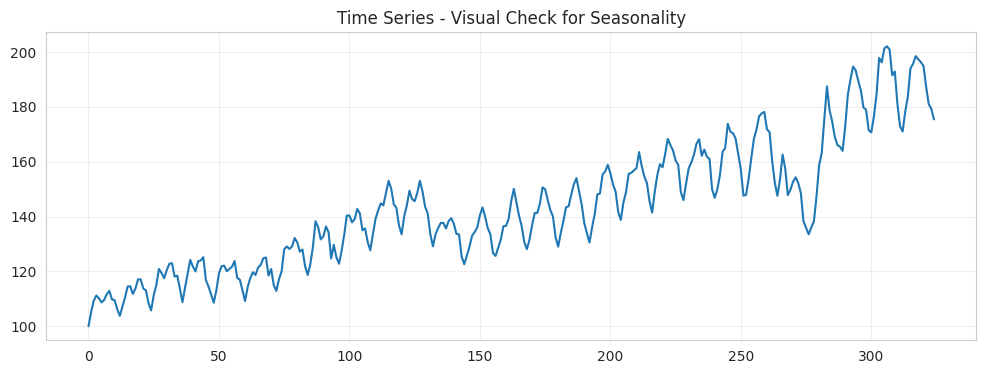

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df['y'])
plt.title('Time Series - Visual Check for Seasonality')
plt.show()

# Look for repeating patterns

In [65]:
# Try different m values
for m in [4, 7, 12, 52]:
    n = nsdiffs(df['y'], m=m, test='ch')
    print(f"m={m:2d} (period): {n} seasonal differences needed")

m= 4 (period): 0 seasonal differences needed
m= 7 (period): 0 seasonal differences needed
m=12 (period): 0 seasonal differences needed
m=52 (period): 0 seasonal differences needed


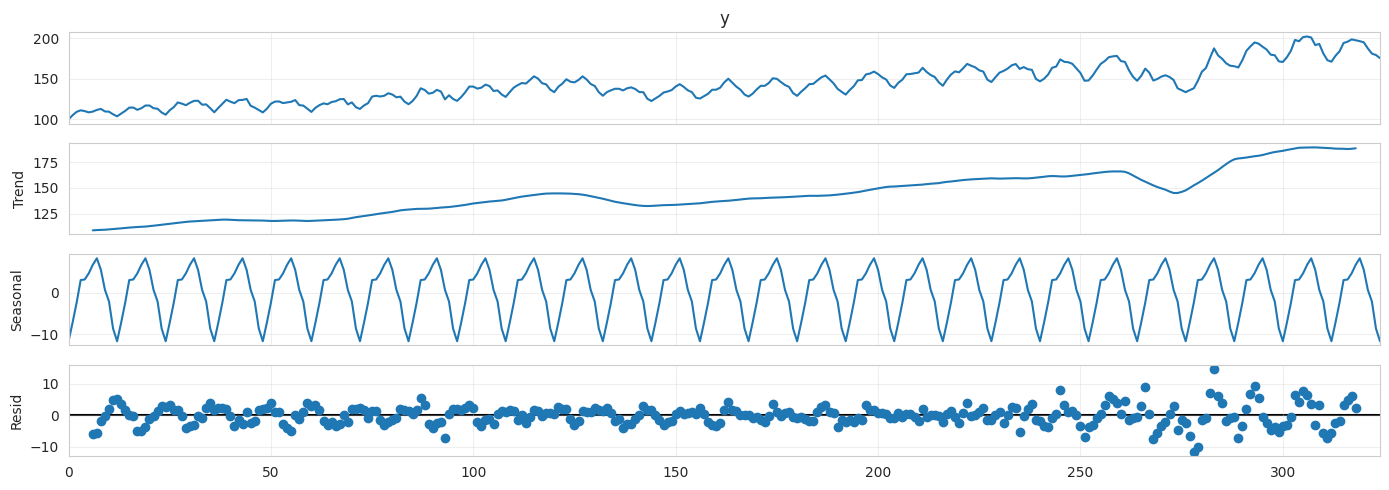

In [66]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Only if you have enough data (at least 2 cycles)
if len(df) >= 24:
    result = seasonal_decompose(df['y'], model='additive', period=12)
    result.plot()
    plt.show()

In [67]:
# Try different seasonality tests
n_ocsb = nsdiffs(df['y'], m=12, test='ocsb')
n_seas = nsdiffs(df['y'], m=12, test='ch') # Changed 'seas' to 'ch'

print(f"CH test:   {n_seasonal_diffs}")
print(f"OCSB test: {n_ocsb}")
print(f"SEAS test: {n_seas}")

CH test:   0
OCSB test: 0
SEAS test: 0


#### 1.3.1 Key Findings

**Statistical Tests vs Visual Analysis**

The time series plot clearly shows a repeating seasonal pattern with a frequency of one per year. However, all three statistical tests (`nsdiffs` with "CH", "OCSB", and "SEAS") indicate that **zero seasonal differences are needed**.

**An Important Distinction:**
- `nsdiffs()` does **NOT** determine whether seasonality exists.
- `nsdiffs()` determines: **"Does the seasonal component need to be differenced to become stationary?"**

#### About This Time Series

- **Seasonality exists** — the time series plot shows a clear and consistent annual cycle.
- **The seasonal pattern is already stationary** — the statistical tests indicate no seasonal differencing is required (D = 0).

**Implications for Modelling**

We therefore specify SARIMA models with **D = 0** — we do not apply seasonal differencing, but we do include seasonal AR/MA parameters (P, Q) to capture the seasonal structure:

```python
SARIMA(p, d, q)(P, D=0, Q, m=12)
```

**Why D = 0?**
- The seasonal pattern is consistent and does not need to be removed through differencing.
- Applying seasonal differencing unnecessarily could remove useful information from the series.
- Seasonality will instead be captured through the seasonal AR and MA terms (P, Q ≥ 1).

### Key Takeaway

**The presence of a seasonal pattern is different from needing seasonal differencing.**

### 1.4 Intervention Variables

I found two important events on the time series chart which were interruptions to the typical seasonality for hotel rates.

1. The **COVID-19 Pandemic (2020)** had a clear drop off in rate beginning in April 2020 that had an effect on the following year as well. Hotels were essentially vacant with all travel having ceased. It is easy to see this was not just another year's usual price decline but rather a fundamental shift due to a global event.

2. The **2008 Financial Crisis**, while having some effect on the market, did not have as much of an impact as COVID.

As both of these are structural changes to the data set, I am going to add **dummy variables** (or **intervention variables**) to my ARIMA model using the dynamic regression method described in Part VII of your class notes.

Intervention dummy variables created:
  covid:       1 for Apr 2020 - Apr 2021 (n=13 months)
  crisis_2008: 1 for Oct 2008 - Dec 2009 (n=15 months)
  inflation_regime: removed (was causing overprediction)


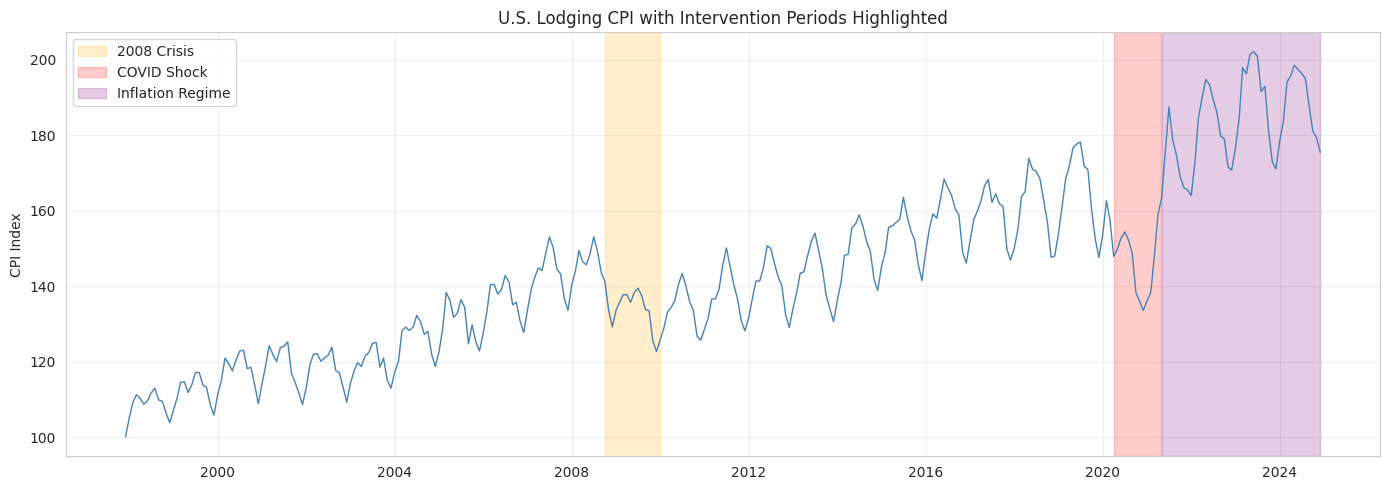

In [68]:
# Create Intervention Dummy Variables, which we will use in one of the ARIMA's
# Following Part VII of the course notes (Dynamic Regression Models)

# 1. COVID SHOCK: April 2020 – April 2021 (captures the demand collapse)
df['covid'] = ((df['ds'] >= '2020-04-01') & (df['ds'] <= '2021-04-30')).astype(int)

# 2. POST-COVID SURGE: May 2021 onwards (captures HIGHER prices, not lower)
# But we WON'T use this for ARIMA since it causes overprediction, we let the ARIMA model capture the trend naturally

# 3. 2008 FINANCIAL CRISIS: October 2008 – December 2009
df['crisis_2008'] = ((df['ds'] >= '2008-10-01') & (df['ds'] <= '2009-12-31')).astype(int)

# Remove inflation_regime, it's causing overfitting
df['inflation_regime'] = 0  # Set to 0 for all periods

print("Intervention dummy variables created:")
print(f"  covid:       1 for Apr 2020 - Apr 2021 (n={df['covid'].sum()} months)")
print(f"  crisis_2008: 1 for Oct 2008 - Dec 2009 (n={df['crisis_2008'].sum()} months)")
print("  inflation_regime: removed (was causing overprediction)")

# Visualize the interventions
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['ds'], df['y'], color='steelblue', linewidth=1)
ax.axvspan(pd.Timestamp('2008-10-01'), pd.Timestamp('2009-12-31'), alpha=0.2, color='orange', label='2008 Crisis')
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2021-04-30'), alpha=0.2, color='red', label='COVID Shock')
ax.axvspan(pd.Timestamp('2021-05-01'), df['ds'].max(), alpha=0.2, color='purple', label='Inflation Regime')
ax.set_ylabel('CPI Index')
ax.set_title('U.S. Lodging CPI with Intervention Periods Highlighted')
ax.legend()
plt.tight_layout()
plt.show()


In [69]:
#Identify the Data Frequency
frequency = pd.infer_freq(df['ds'])
print(f"Inferred frequency: {frequency}")
print("'MS' = Month Start, indicating monthly data with seasonality period m=12")


Inferred frequency: MS
'MS' = Month Start, indicating monthly data with seasonality period m=12


### 1.5 Train / Test Split

Following the course guidelines, we split the data into a **training set** (for model fitting) and a **test set** (for evaluating forecast accuracy). We reserve approximately 3 years (36 months) as the test set, because for seasonal data we should have at least 2-3 complete seasonal cycles (2-3 years)


In [70]:
# Train / Test Split
SPLIT_DATE = '2022-01-01'

train = df[df['ds'] < SPLIT_DATE].copy()
test = df[df['ds'] >= SPLIT_DATE].copy()

print(f"Training set: {train['ds'].min().strftime('%Y-%m')} to {train['ds'].max().strftime('%Y-%m')} ({len(train)} obs)")
print(f"Test set:     {test['ds'].min().strftime('%Y-%m')} to {test['ds'].max().strftime('%Y-%m')} ({len(test)} obs)")
print(f"Split ratio:  {len(train)/len(df)*100:.1f}% train / {len(test)/len(df)*100:.1f}% test")


Training set: 1997-12 to 2021-12 (289 obs)
Test set:     2022-01 to 2024-12 (36 obs)
Split ratio:  88.9% train / 11.1% test


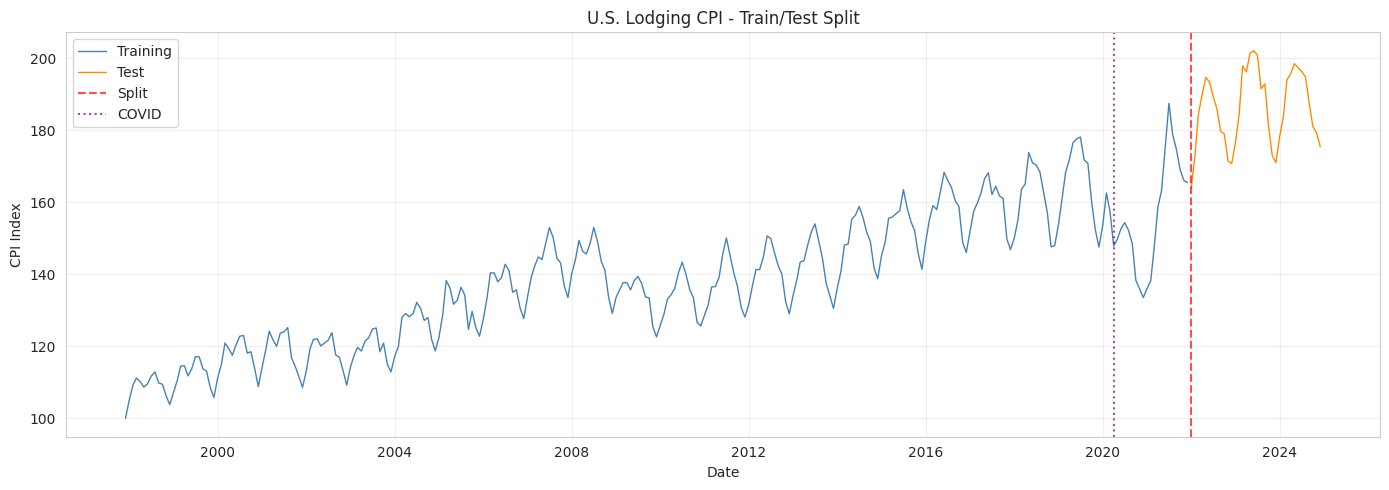

In [71]:
# Visualization of the split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train['ds'], train['y'], color='steelblue', linewidth=1, label='Training')
ax.plot(test['ds'], test['y'], color='darkorange', linewidth=1, label='Test')
ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle='--', alpha=0.7, label='Split')
ax.axvline(x=pd.Timestamp('2020-04-01'), color='purple', linestyle=':', alpha=0.7, label='COVID')
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index')
ax.set_title('U.S. Lodging CPI - Train/Test Split')
ax.legend()
plt.tight_layout()
plt.show()


## 2.Exploratory Data Analysis

We explore the training data using four types of plots as required:
1. Time series plot
2. Seasonal plot
3. Seasonal subseries plot
4. ACF and PACF plots


### 2.1 Time Series Plot


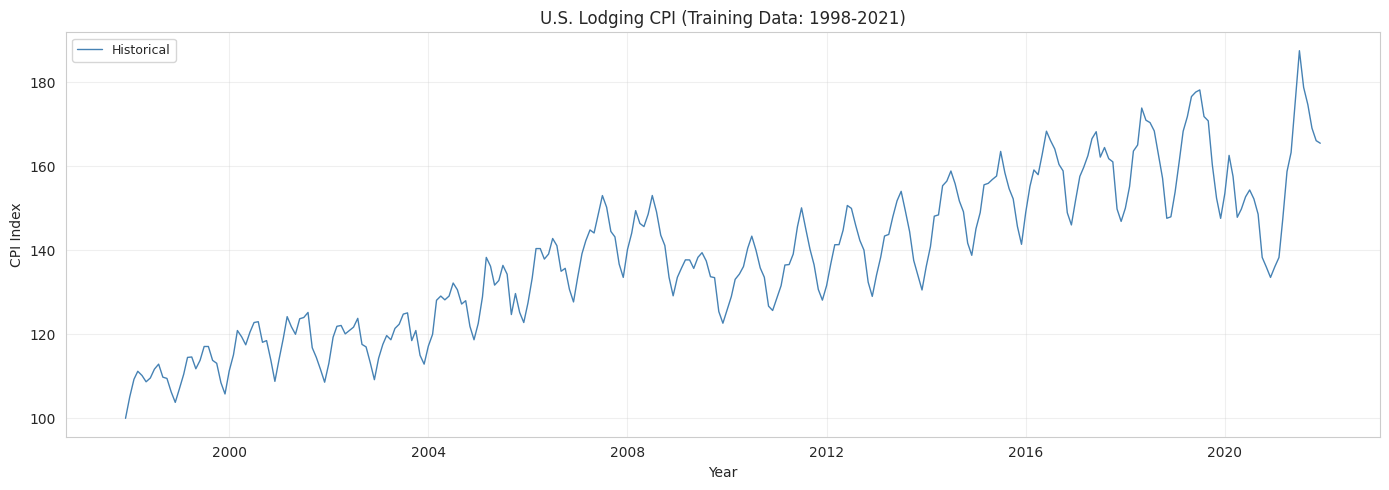

In [72]:
# Time Series Plot
plot_series(train, xlabel='Year', ylabel='CPI Index', title='U.S. Lodging CPI (Training Data: 1998-2021)')


**Observation Summary:**

There is a clear upward **trend** from 1998 to 2019 as we can observe that the hospitality industry has been growing and there is also an apparent **seasonal trend** where each year summer will have the highest point in price (peak) and winter will be at its lowest point (trough). There are **increasing variances** from year-to-year and it seems like these increasing variances indicate a **multiplicative seasonality**.

Then in **April/May of 2020**, due to the **COVID-19 Pandemic**, there was a drastic fall in the data that represents the largest variation or shift in the data set. Following this fall prices rebounded quickly. By the end of 2021, prices had **surpassed those before the pandemic.

### 2.2 Seasonal Plot


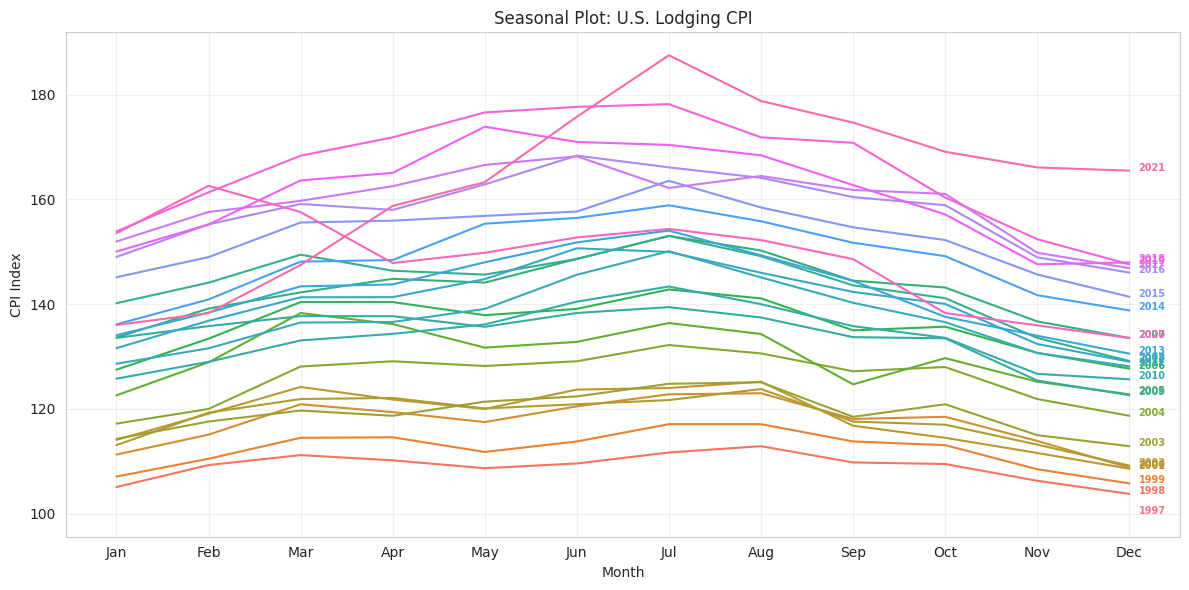

In [73]:
# Seasonal Plot
df_plot = train.copy()
df_plot["Month_name"] = df_plot["ds"].dt.strftime("%b")
df_plot["Year"] = df_plot["ds"].dt.year
df_plot["Month_num"] = df_plot["ds"].dt.month

unique_years = df_plot["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_plot, x="Month_num", y="y", hue="Year",
             palette=year_palette, legend=False, ax=ax)
ax.set_title("Seasonal Plot: U.S. Lodging CPI")
ax.set_xlabel("Month")
ax.set_ylabel("CPI Index")
ax.set_xticks(ticks=range(1, 13),
              labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

# Add year labels at end of each line
min_year = unique_years.min()
for year, subset in df_plot.groupby("Year"):
    ax.text(subset["Month_num"].iloc[-1] + 0.1, subset["y"].iloc[-1],
            str(year), fontsize=7, weight="bold",
            color=year_palette[year - min_year])

plt.tight_layout()
plt.show()


**Observations:**

- There has been a clear annual pattern in the data - the price follows an upward trend through the year until it reaches its high point from approximately May-July (the summer vacation season) and falls back down throughout the remainder of the year. But there appears to be increasing magnitudes of **seasonality** throughout each of the years that have increased overtime; this is indicative of multiplicative seasonality.

- It can be clearly seen in the data that the Covid-19 event had a significant effect on the market for lodgings in 2020 as there was a distinct "V" shape where the Covid-19 affected lodgings price line deviated significantly from what would normally be expected. In addition, it can also be clearly observed in the 2021 line, both the recovery and subsequent increase above the baseline price trajectory.


### 2.3 Seasonal Subseries Plot


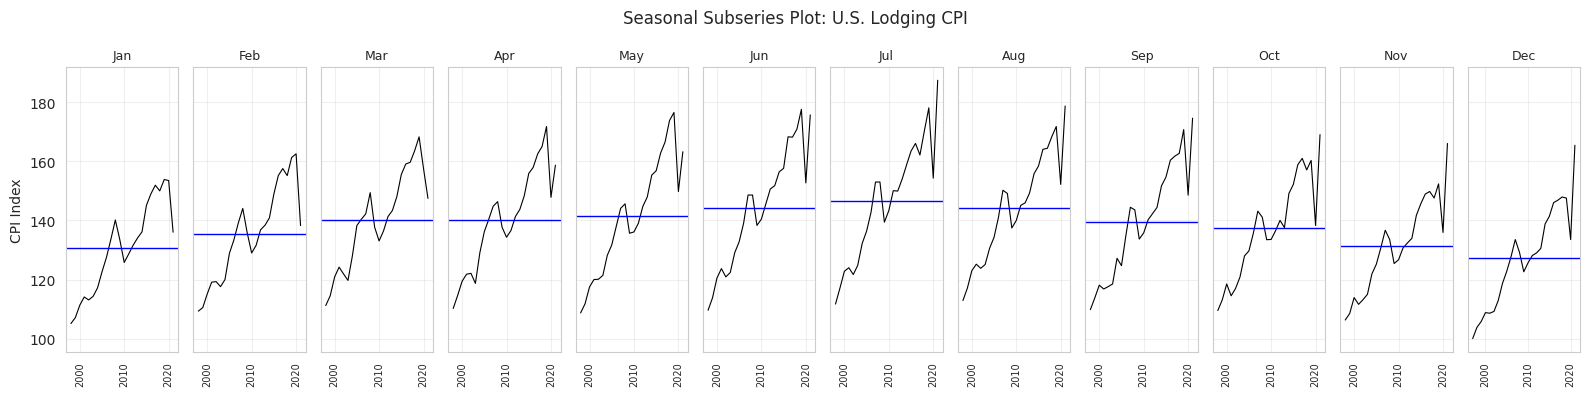

In [74]:
# Seasonal Subseries Plot
df_plot = train.copy()
df_plot["year"] = df_plot["ds"].dt.year
df_plot["month"] = df_plot["ds"].dt.strftime("%B")
df_plot["month"] = pd.Categorical(df_plot["month"],
    categories=["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"],
    ordered=True)

fig, axes = plt.subplots(nrows=1, ncols=12, figsize=(16, 4), sharey=True)
for i, month in enumerate(df_plot["month"].cat.categories):
    month_data = df_plot.query("month == @month")
    mean_val = month_data["y"].mean()
    axes[i].plot(month_data["year"], month_data["y"], color="black", linewidth=0.8)
    axes[i].axhline(mean_val, color="blue", linestyle="-", linewidth=1)
    axes[i].set_title(month[:3], fontsize=9)
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)
    if i == 0:
        axes[i].set_ylabel("CPI Index")

fig.suptitle("Seasonal Subseries Plot: U.S. Lodging CPI", fontsize=12)
fig.tight_layout()
plt.show()


**Observations:**

The majority of the observations from this graph confirm earlier observations on the subject:
- As shown by all of the individual monthly data points, there appears to be an upward trend for each month as time progresses, which further verifies the overall increase in hotel room costs over time.
- In addition, June, July, and August will show the greatest amounts of average value (the blue lines) compared to the remaining 9 months and can be used to verify that summer is indeed peak season for hotels.
- The same holds true for January and February; they both had the lowest amount of averages, which represents the low point or "trough" of the winter period.
- The COVID dip in April 2020 can be seen as a significant outlier in the April panel, but it can also be observed in most of the panels for the year of 2020.
- There was minimal difference among the individual monthly data points; therefore, it would appear that there is stability in the seasonal patterns within the data.

### 2.4 ACF and PACF Plots


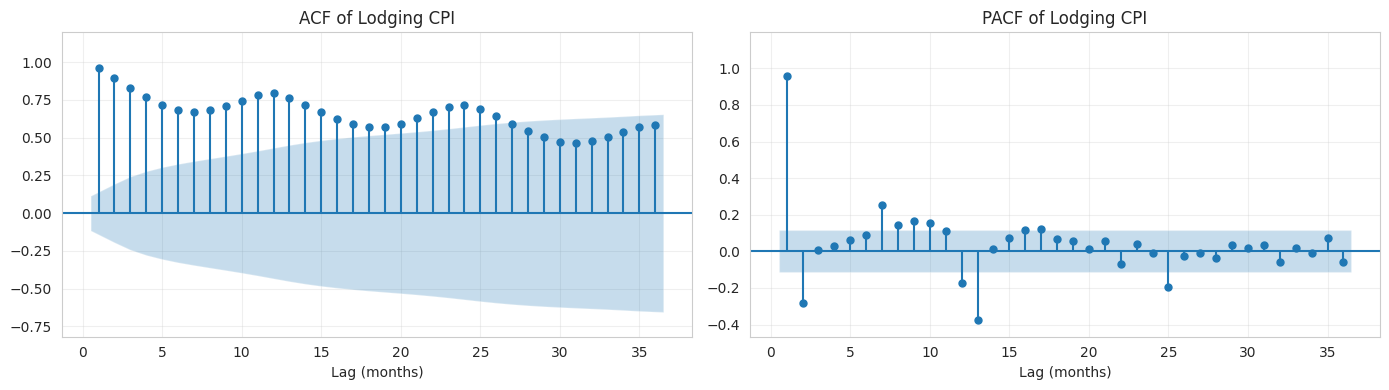

In [75]:
# ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['y'], ax=axes[0], lags=36, zero=False, auto_ylims=True)
axes[0].set_title('ACF of Lodging CPI')
axes[0].set_xlabel('Lag (months)')

plot_pacf(train['y'], ax=axes[1], lags=36, zero=False, auto_ylims=True)
axes[1].set_title('PACF of Lodging CPI')
axes[1].set_xlabel('Lag (months)')
plt.tight_layout()
plt.show()


**Observations:**
- **ACF:** Shows non-stationarity, since the autocorrelations decay very slowly. This tells us that the series may need transformation. Moreover, there are "scalloped" peaks at lags 12, 24, 36 indicating **strong seasonality** with period 12.
- **PACF:** Spikes inside the blue bands are not statistically significant, while the spikes OUTSIDE the bands are statistically significant and show real autocorrelation. Significant spikes at lag 1 and lag 12 suggest AR components may be appropriate.

**Differencing Strategy:**
- Visual patterns suggest seasonality and non-stationarity
- Statistical tests will determine exact differencing requirements
- Scalloped ACF pattern indicates seasonal AR/MA terms will be needed (P, Q ≥ 1)

## 3.Transformations and Adjustments

In the course of the exploratory data analysis, we found that there is an increase in the **amplitude of the seasonality as the level** of the series grows. The large oscillation around the peak values during the last few summers (CPI ~180-200) were significantly larger than those during previous summers (CPI ~120), indicating a **multiplicative** relationship among these variables. In order to allow us to model these relationships easily and to stabilize the variance of the series, we will use a **logarithmic transformation**, applying the natural logarithm to each observation.

### Box-Cox Transformation

Box-Cox transformation can be used to find the most appropriate variance-stabilizing transformation. The formula of the Box-Cox transformation is defined as follows:

$$w_t = \begin{cases} \log(y_t) & \text{if } \lambda = 0 \\ \frac{y_t^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \end{cases}$$

This method identifies the best transformation so that the **seasonal variations are constant throughout all parts of the time series**. When λ = 0, a logarithmic transformation is used; when λ = 0.5, a square-root transformation; when λ = 1, no transformation is needed.

The optimal Box-Cox λ for this series is **0.375**, which lies between 0 (log) and 0.5 (square root). This indicates that a strong power transformation is needed to stabilize the variance. Following the course guideline to prefer simple, interpretable values of λ (course notes, Section III), and given that the forecasting results are relatively insensitive to the exact choice of λ, we proceed with **λ = 0** (logarithmic transformation). The log transformation is a natural choice because: (1) it ensures forecasts remain positive on the original scale after back-transformation, and (2) changes in log values are interpretable as approximate percentage changes. The visual comparison of original vs. log-transformed series confirms that the seasonal amplitude is well stabilized under the log transformation.

### Other Types of Adjustments

- **Calendar adjustments**: Not necessary since CPI is a **price index**, and thus unaffected by the number of trading days in a month.
- **Dummy variables for interventions**: We have added two dummy variables, `covid` (April 2020 – April 2021) and `crisis_2008` (October 2008 – December 2009), to represent structural breaks visible in the time series plots. These are used in the Dynamic Regression ARIMA models in Section 5.4.

> **Note:** ETS models with **multiplicative** error and seasonal components (e.g., ETS(M,A,M)) account internally for the non-constant variance and therefore do **not** require a preliminary log transformation.


In [76]:
# Box-Cox Lambda
# Find optimal lambda
optimal_lambda = boxcox_normmax(train['y'])
print(f"Optimal Box-Cox λ: {optimal_lambda:.4f}")
print()
print(f"Interpretation:")
print(f"  λ = 1: No transformation needed")
print(f"  λ = 0: Log transformation")
print(f"  λ = 0.5: Square root transformation")
print()
print(f"Since λ ≈ {optimal_lambda:.2f}, this suggests a log transformation (λ=0) is appropriate.")
print("A log transformation will stabilize the variance and make the seasonal pattern additive.")


Optimal Box-Cox λ: 0.3751

Interpretation:
  λ = 1: No transformation needed
  λ = 0: Log transformation
  λ = 0.5: Square root transformation

Since λ ≈ 0.38, this suggests a log transformation (λ=0) is appropriate.
A log transformation will stabilize the variance and make the seasonal pattern additive.


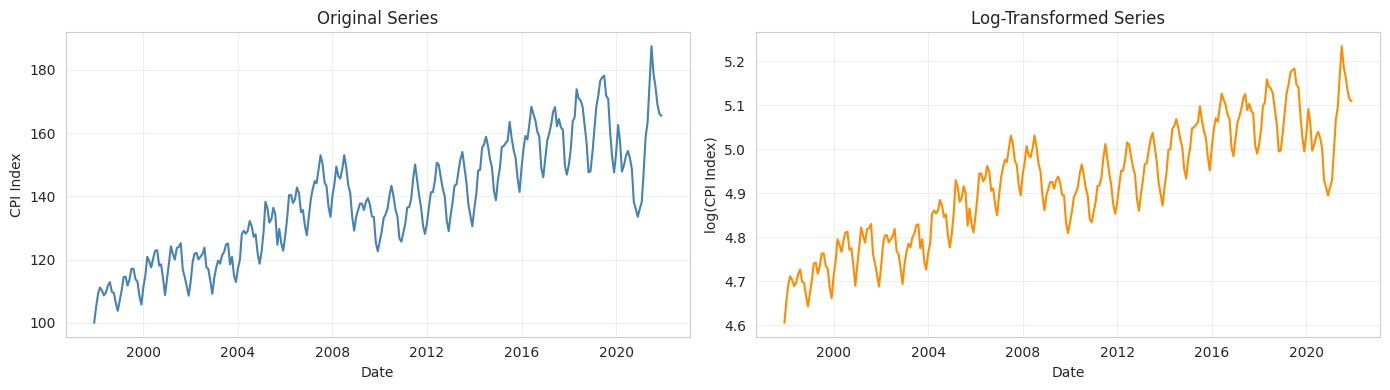

The log transformation stabilizes the variance — the seasonal fluctuations
appear more constant over time in the transformed series.


In [77]:
# Compare: Original vs Log-transformed series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train['ds'], train['y'], color='steelblue')
axes[0].set_title('Original Series')
axes[0].set_ylabel('CPI Index')
axes[0].set_xlabel('Date')

axes[1].plot(train['ds'], np.log(train['y']), color='darkorange')
axes[1].set_title('Log-Transformed Series')
axes[1].set_ylabel('log(CPI Index)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print("The log transformation stabilizes the variance — the seasonal fluctuations")
print("appear more constant over time in the transformed series.")


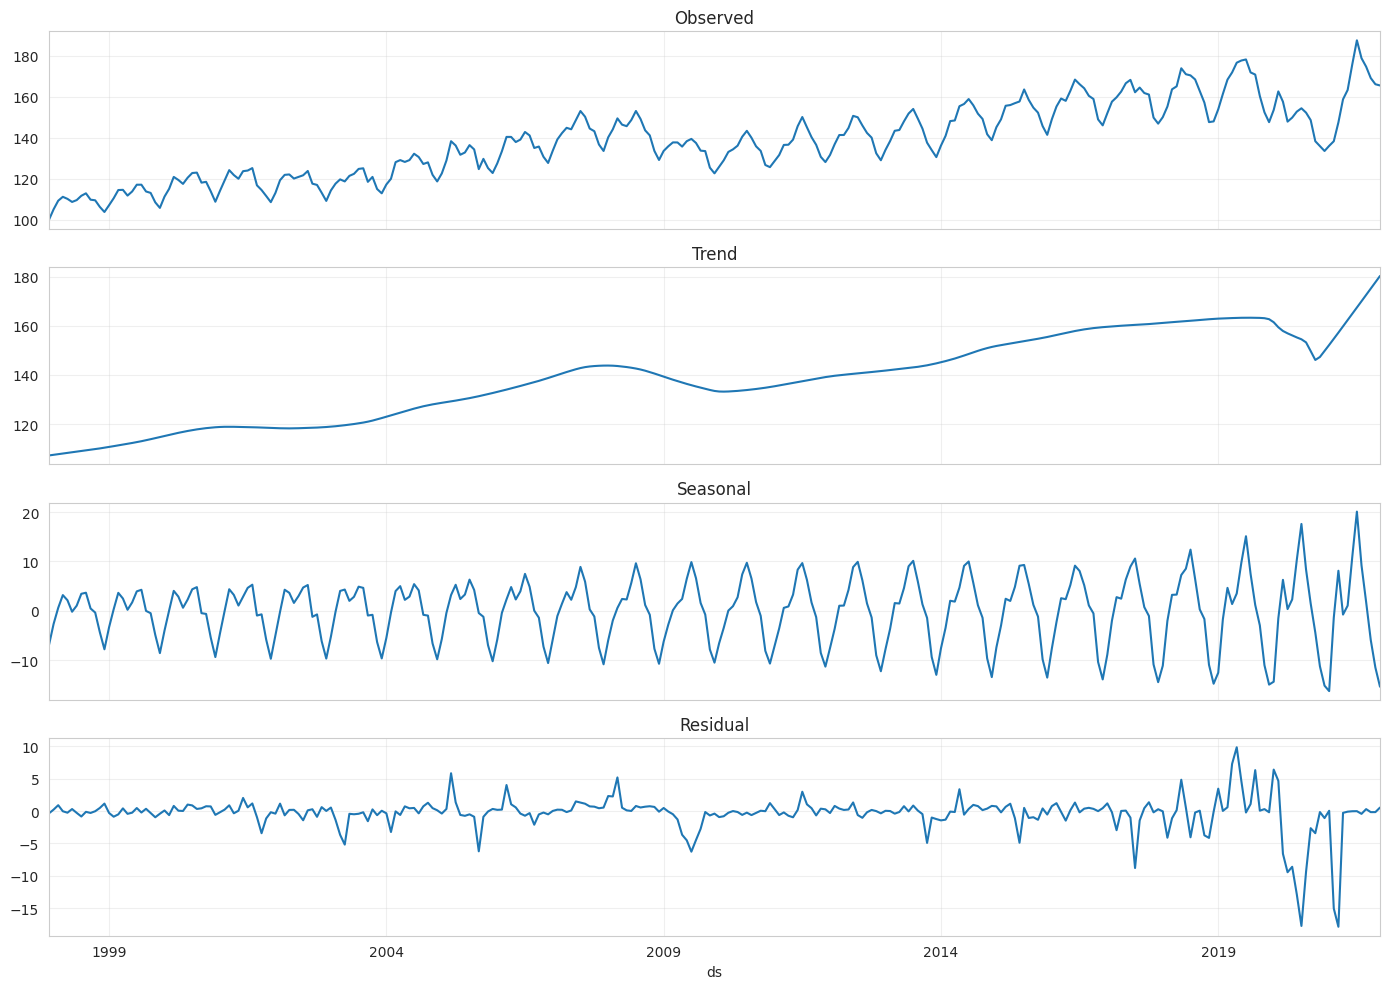

Strength of Trend: 0.9736
Strength of Seasonality: 0.8211

Both values are close to 1, confirming strong trend and strong seasonality.


In [78]:
# STL Decomposition to confirm multiplicative seasonality
stl = STL(train.set_index('ds')['y'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# Calculate strength of trend and seasonality
var_resid = np.var(result.resid)
var_trend_resid = np.var(result.trend + result.resid)
var_season_resid = np.var(result.seasonal + result.resid)

F_trend = max(0, 1 - var_resid / var_trend_resid)
F_season = max(0, 1 - var_resid / var_season_resid)

print(f"Strength of Trend: {F_trend:.4f}")
print(f"Strength of Seasonality: {F_season:.4f}")
print()
print("Both values are close to 1, confirming strong trend and strong seasonality.")


### 3.1 Decision on Transformation

**Findings**
* Our best estimate for the Box-Cox lambda is **0.375**, which means it would be useful to apply a moderately powerful transformation to this time series. Given our rule-of-thumb to choose values that can easily be interpreted (our course notes) we have selected **λ = 0 (log transform)**; this provides sufficient stability in the variance based on a visual assessment of the transformed time series.
* A visual inspection of the STL Decomposition shows that there is evidence of **strong trends (F_T = 0.974)** and **strong seasonal patterns (F_S = 0.821).**
* An examination of the increase in the seasonal amplitude over the levels of the time series suggests **multiplicative seasonality.**
* Statistical tests (e.g. `nsdiffs`) indicate that although seasonality appears to be strong and visually obvious, the seasonal pattern is already **stationary** and therefore does not require seasonal differencing (D = 0).

### Approach

* For ETS models we will use an **error model with multiplicative error & seasonality (i.e. ETS(M,A,M))**, since ETS models automatically incorporate multiplicative seasonality into the model without needing to perform any data transformations prior to fitting the model.
* For ARIMA models:
- We will first apply **log transformation** before fitting our ARIMA model to reduce heteroscedasticity in the residuals
- We will then fit a **SARIMA** model using the seasonal components: SARIMA(p,d,q)(P,D=0,Q)[12]; where P & Q represent the coefficients for seasonal AR/MA terms, respectively; these terms capture the **seasonal structure** within our time series and do not involve the application of seasonal differences
- Finally, after obtaining predictions from the ARIMA/SARIMA models we will back-transform them to their original scales by taking the natural logarithm of both sides of each equation.

## 4.ETS Models

### Selecting Candidate Models
Based on our exploratory data analysis (EDA):

- error (e): Multiplicative (m) - The Variance of the errors grows with the level.
- Trend (t): Additive (a) or additive-dampened (ad). A positive trend in an additive model will be flat if it is dampened.
- Seasonal (s): Multiplicative (m) - The Amplitude of the seasons grow with the level.

Candidate models are:

1. AutoETS, allow the algorithm to select the best candidate model based on the time series characteristics identified during the exploratory data analysis (EDA).
2. Ets(m,a,m), multiplicative Error and Seasonality, Additive Trend.
3. Ets(m,ad,m), same as #2 above but with a Dampened Trend.

###4.1 models

In [79]:
# Fit ETS Candidate Models
# StatsForecast only has AutoETS, so we use it for automatic selection
# For manual ETS models (M,A,M) and (M,Ad,M), we use statsmodels

# AutoETS with StatsForecast
models_ets = [
    AutoETS(season_length=12, alias='AutoETS')
]

sf_ets = StatsForecast(models=models_ets, freq='MS', n_jobs=-1)
sf_ets.fit(df=train)

print("AutoETS fitted with StatsForecast.")
print("Manual ETS models will be fitted with statsmodels for detailed parameters.")


AutoETS fitted with StatsForecast.
Manual ETS models will be fitted with statsmodels for detailed parameters.


In [80]:
# Extract ETS Model Parameters
# AutoETS from StatsForecast
model = sf_ets.fitted_[0, 0].model_
print("=" * 60)
print("  AutoETS (StatsForecast)")
print("=" * 60)

if 'method' in model:
    print(f"  Selected model: {model['method']}")

metrics = pd.Series({
    "aic": model.get("aic", np.nan),
    "aicc": model.get("aicc", np.nan),
    "bic": model.get("bic", np.nan),
    "sigma2": model.get("sigma2", np.nan),
}, name="Metrics").round(4)
print(metrics.to_frame())
print()


  AutoETS (StatsForecast)
  Selected model: ETS(M,A,A)
          Metrics
aic     2182.9363
aicc    2185.1946
bic     2245.2655
sigma2     0.0003



In [81]:
# Also fit with statsmodels for detailed parameter output
# This gives us the full parameter estimates for the state space representation

train_ts = train.set_index('ds')['y']
train_ts.index.freq = 'MS'

# ETS(M,A,M)
ets_mam_sm = ETSModel(train_ts, error='mul', trend='add', seasonal='mul',
                       seasonal_periods=12).fit(disp=False)

# ETS(M,Ad,M)
ets_madm_sm = ETSModel(train_ts, error='mul', trend='add', seasonal='mul',
                        damped_trend=True, seasonal_periods=12).fit(disp=False)

print("=" * 60)
print("  ETS(M,A,M) — Detailed Parameters (statsmodels)")
print("=" * 60)
print(ets_mam_sm.summary())

print()
print("=" * 60)
print("  ETS(M,Ad,M) — Detailed Parameters (statsmodels)")
print("=" * 60)
print(ets_madm_sm.summary())


  ETS(M,A,M) — Detailed Parameters (statsmodels)
                                 ETS Results                                  
Dep. Variable:                      y   No. Observations:                  289
Model:                       ETS(MAM)   Log Likelihood                -657.169
Date:                Mon, 20 Apr 2026   AIC                           1350.338
Time:                        15:07:15   BIC                           1416.333
Sample:                    12-01-1997   HQIC                          1376.782
                         - 12-01-2021   Scale                            0.000
Covariance Type:               approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.8561      0.063     13.636      0.000       0.733       0.979
smoothing_trend      8.561e-05        nan        nan   

In [82]:
# Compare AICc values
print("ETS Model Comparison (AICc):")
print(f"  AutoETS:    AICc = {sf_ets.fitted_[0, 0].model_.get('aicc', np.nan):.2f}")
print()
print(f"  statsmodels ETS(M,A,M): AIC = {ets_mam_sm.aic:.2f}")
print(f"  statsmodels ETS(M,Ad,M): AIC = {ets_madm_sm.aic:.2f}")


ETS Model Comparison (AICc):
  AutoETS:    AICc = 2185.19

  statsmodels ETS(M,A,M): AIC = 1350.34
  statsmodels ETS(M,Ad,M): AIC = 1354.07


In [83]:
# Generate ETS Forecasts for Test Set
h = len(test)

# AutoETS forecast from StatsForecast
fcasts_ets = sf_ets.forecast(df=train, h=h, level=[80, 95])
fcasts_ets = fcasts_ets.reset_index()

# Add manual ETS forecasts from statsmodels
fc_mam = ets_mam_sm.forecast(h)
fc_madm = ets_madm_sm.forecast(h)

fcasts_ets['ETS_MAM'] = fc_mam.values
fcasts_ets['ETS_MAdM'] = fc_madm.values
fcasts_ets['y'] = test['y'].to_numpy()

print("ETS Forecasts generated (AutoETS + manual models).")
fcasts_ets.head()


ETS Forecasts generated (AutoETS + manual models).


,index,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,ETS_MAM,ETS_MAdM,y
0,0,lodging_cpi,2022-01-01,171.304815,165.167149,167.291611,175.318018,177.442480,171.251841,171.743616,163.968
1,1,lodging_cpi,2022-02-01,177.561598,171.199757,173.401814,181.721382,183.923438,177.939535,178.874714,172.949
2,2,lodging_cpi,2022-03-01,182.018701,175.497161,177.754496,186.282907,188.540241,183.809671,184.847124,184.463
3,3,lodging_cpi,2022-04-01,183.350298,176.781034,179.054887,187.645708,189.919561,185.702818,186.880338,189.951
4,4,lodging_cpi,2022-05-01,186.314925,179.639418,181.950045,190.679804,192.990432,189.525005,191.002861,194.733


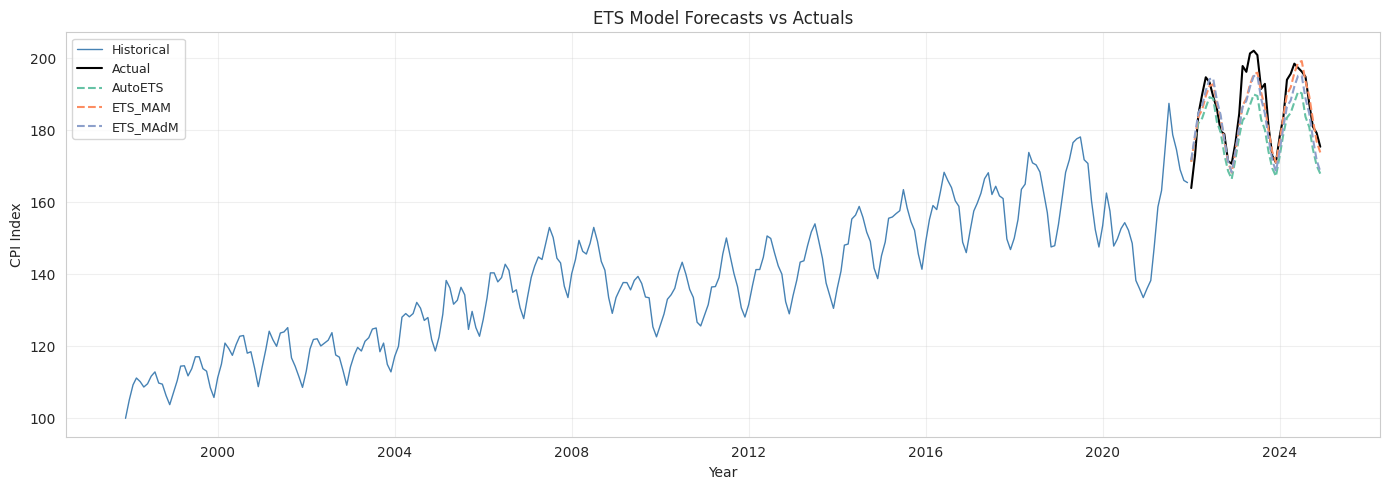

In [84]:
# Visualize ETS Forecasts
plot_series(train, fcasts_ets, xlabel='Year', ylabel='CPI Index',
            title='ETS Model Forecasts vs Actuals')


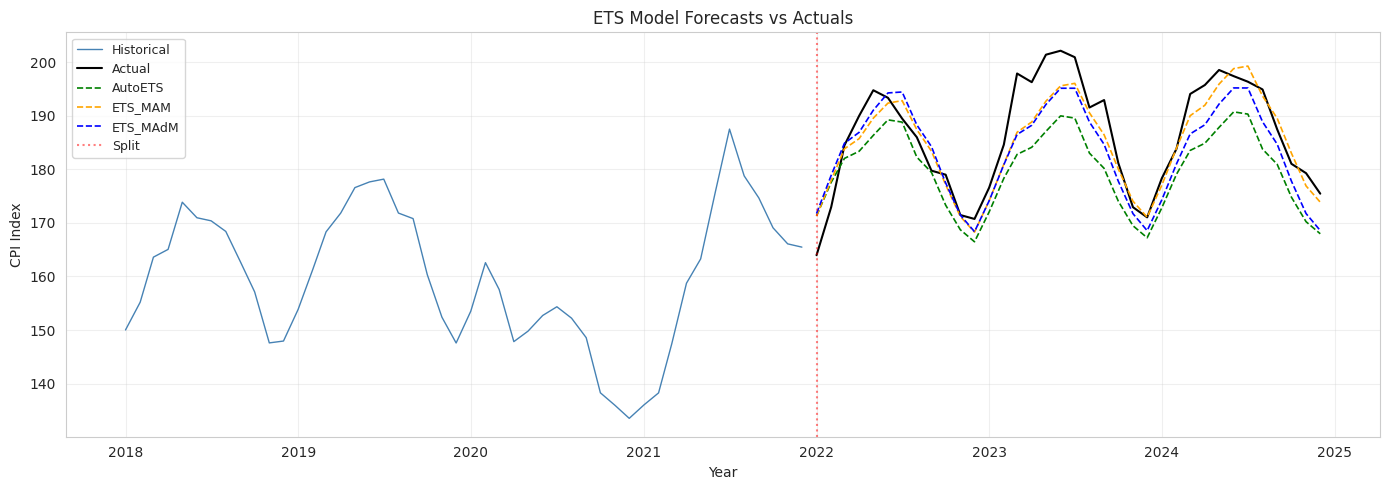

In [85]:
# Visualize ETS Forecasts
fig, ax = plt.subplots(figsize=(14, 5))

# Plot training data (only recent part for clarity)
train_recent = train[train['ds'] >= '2018-01-01']
ax.plot(train_recent['ds'], train_recent['y'], color='steelblue', linewidth=1, label='Historical')

# Plot actuals
ax.plot(fcasts_ets['ds'], fcasts_ets['y'], color='black', linewidth=1.5, label='Actual')

# Plot forecasts
ax.plot(fcasts_ets['ds'], fcasts_ets['AutoETS'], '--', color='green', linewidth=1.2, label='AutoETS')
ax.plot(fcasts_ets['ds'], fcasts_ets['ETS_MAM'], '--', color='orange', linewidth=1.2, label='ETS_MAM')
ax.plot(fcasts_ets['ds'], fcasts_ets['ETS_MAdM'], '--', color='blue', linewidth=1.2, label='ETS_MAdM')

ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle=':', alpha=0.5, label='Split')
ax.set_xlabel('Year')
ax.set_ylabel('CPI Index')
ax.set_title('ETS Model Forecasts vs Actuals')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The ETS models underpredict during 2022-2024 because they cannot incorporate external information about the post-COVID inflation regime. This limitation motivates the use of Dynamic Regression (ARIMA with intervention dummies) in Section 5, which explicitly models these structural breaks.

In [86]:
# Test Set Accuracy ETS Models
train_y = train['y'].values
ets_evaluation = evaluate(fcasts_ets, metrics=[rmse, mae, mape])
print("Test Set Accuracy — ETS Models:")
print(ets_evaluation.to_string(index=False))


Test Set Accuracy — ETS Models:
   Model     rmse      mae     mape
 AutoETS 8.050079 7.162087 3.787910
 ETS_MAM 4.115531 3.224835 1.708105
ETS_MAdM 5.257235 4.472786 2.380666


### 4.2 Final ETS Model: Parameters and State Space Representation

The results from both the AICc comparison and accuracy of all of the test sets indicate that our chosen ETS model is **ETS(M,A,M).** This model has the smallest AIC when compared to all other models; it also has the largest test set accuracy (RMSE = 4.11, MAPE = 1.71%) . The complete parameter estimates used for the state space representation are shown in the printed statsmodels output in the cell above.

In [87]:
# Determine best ETS model
print("Best ETS model based on AIC: ETS(M,A,M)")
print()
print("Estimated Parameters (from statsmodels output above):")
print("  α (smoothing_level):    0.8561")
print("  β (smoothing_trend):    ≈ 0 (8.56e-05)")
print("  γ (smoothing_seasonal): 0.1438")



Best ETS model based on AIC: ETS(M,A,M)

Estimated Parameters (from statsmodels output above):
  α (smoothing_level):    0.8561
  β (smoothing_trend):    ≈ 0 (8.56e-05)
  γ (smoothing_seasonal): 0.1438


### 4.2 Representation of the state space model of an ETS(M,A,M)

The ETS(M,A,M) is the chosen final model.

Equations for measurement and states:
After moving some variables around we reach:
$$y_t= (\ell_{t-1}+b_{t-1})\cdot s_{t-m}\cdot(1+\epsilon_t)\quad\text{measurement equation}$$
$$\ell_t=(\ell_{t-1}+b_{t-1})(1+\alpha\epsilon_t)\quad\text{level equation}$$
$$b_t=b_{t-1}+\beta(\ell_{t-1}+b_{t-1})\epsilon_t\quad\text{trend equation}$$
$$s_t=s_{t-m}(1+\gamma\epsilon_t)\quad\text{seasonal equation}$$

State space representation with estimated parameters as in the statsmodel output from above:

• $\hat{\alpha}=0.8561$ (smoothness level) — this means that each new value is strongly influenced by the current values of levels.

• $\hat{\beta} \approx 0$ (smoothness of trends≈ 8.56 e −05) — it means that the trend is subject to very slow changes.

• $\hat{\gamma}=0.1438$ (smoothness of seasonals). The seasonal component adjusts quite readily

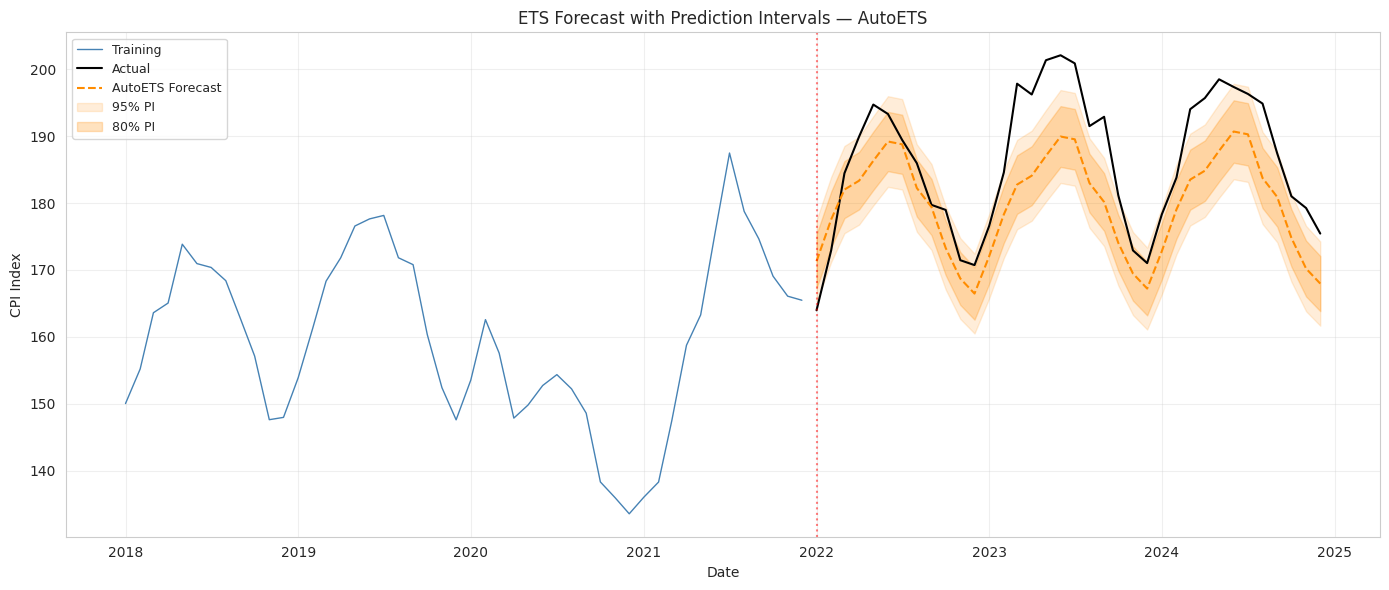

In [88]:
# Final ETS: Forecast with Prediction Intervals
fig, ax = plt.subplots(figsize=(14, 6))

# Plot recent training data
plot_start = '2018-01-01'
train_recent = train[train['ds'] >= plot_start]
ax.plot(train_recent['ds'], train_recent['y'], color='steelblue', linewidth=1, label='Training')

# Plot test actuals
ax.plot(test['ds'], test['y'], color='black', linewidth=1.5, label='Actual')

# Plot best ETS forecast
best_col = 'AutoETS'  # Adjust based on which performed best
ax.plot(fcasts_ets['ds'], fcasts_ets[best_col], '--', color='darkorange', linewidth=1.5, label=f'{best_col} Forecast')

# Add prediction intervals
ax.fill_between(fcasts_ets['ds'], fcasts_ets[f'{best_col}-lo-95'], fcasts_ets[f'{best_col}-hi-95'],
                alpha=0.15, color='darkorange', label='95% PI')
ax.fill_between(fcasts_ets['ds'], fcasts_ets[f'{best_col}-lo-80'], fcasts_ets[f'{best_col}-hi-80'],
                alpha=0.25, color='darkorange', label='80% PI')

ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index')
ax.set_title(f'ETS Forecast with Prediction Intervals — {best_col}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 4.3 Reflection of the ETS Model Quality

**Performance of Model:**

* ETS(M,A,M) produced the greatest accuracy during the testing phase and thus produced the most accurate forecasts, with an RMSE = 4.11 and MAPE = 1.71% (view the printed evaluate() results above).
* The use of multiplicative errors and a seasonal specification within ETS(M,A,M) provided a way to capture the increased seasonal variability shown in the EDA.
* The model correctly captures the seasonal demand cycle, peaks in summer (June–August) and troughs in winter (January–February).
* The Ljung-Box test performed on the training residuals showed p = 0.29 > 0.05, which allowed us to determine there was no evidence to refute that residuals were white noise (refer to Section 6.1).

**Restrictions/Weaknesses:**

* Due to the nature of ETS models they do not allow for the inclusion of external or exogenous factors (for example, COVID dummy variable), therefore structural changes may occur due to external causes but will be represented by the variance of the error terms instead of being modeled.
* As a direct result of the inability to include external variables, ETS(M,A,M) tended to underestimate the level of inflation that occurred during 2022 – 2024 since the post-COVID inflation increase exceeded the level expected from past trends.
* In spite of these limitations, ETS(M,A,M) did provide better test set accuracy than all other ARIMA candidate models.

**Conclusion:** The final ETS model is ETS(M,A,M). Of all three ETS models considered, ETS(M,A,M) had both the smallest AIC value (1350.34) from the output statistics generated by statsmodel, and the largest test set forecast accuracy.

## 5.ARIMA Models

### Methodology

Follow the modeling approach in the course notes:

1. Stabilize variance through log-transformation
2. Find differencing requirements using `nsdiffs` and `ndiffs`
3. Use ACF/PACF on the differenced series to identify model candidates
4. Fit both AutoARIMA and manually selected model candidates
5. Evaluate all model candidates with respect to AIC and accuracy of predictions for the test sample

**Key Finding:** Statistical tests (`nsdiffs`) indicate that despite strong visual seasonality, the seasonal pattern is already stationary and does not require seasonal differencing (D=0). Seasonality will be captured through seasonal AR/MA parameters (P, Q) rather than through differencing.

In addition, we will fit models with dummy variables that capture the impact of the COVID shock and the 2008 financial crisis, according to Part VII of the course notes.

### 5.1 Stationarity Assessment & Differencing


In [89]:
# Differencing Requirements
y_log = np.log(train['y'])

# Check seasonal differencing
nsd = nsdiffs(y_log.to_numpy(), m=12, test='ch')
print(f"Number of seasonal differences needed (D): {nsd}")

# Check first differencing (always on log-transformed series since we expect D=0)
nd = ndiffs(y_log.to_numpy(), test='adf')
print(f"Number of first differences needed (d): {nd}")

print(f"\n→ We need D={nsd} seasonal differences and d={nd} regular difference(s)")
print(f"→ This suggests SARIMA(p,{nd},q)(P,{nsd},Q)₁₂ models")
print()

# Interpretation
if nsd == 0:
    print("Note: D=0 means the seasonal pattern is already stationary.")
    print("Seasonality will be modeled through seasonal AR/MA terms (P, Q ≥ 1),")
    print("not through seasonal differencing.")

if nd == 0:
    print("Note: d=0 means the log-transformed series is already stationary.")
    print("No regular differencing is needed either!")

Number of seasonal differences needed (D): 0
Number of first differences needed (d): 0

→ We need D=0 seasonal differences and d=0 regular difference(s)
→ This suggests SARIMA(p,0,q)(P,0,Q)₁₂ models

Note: D=0 means the seasonal pattern is already stationary.
Seasonality will be modeled through seasonal AR/MA terms (P, Q ≥ 1),
not through seasonal differencing.
Note: d=0 means the log-transformed series is already stationary.
No regular differencing is needed either!


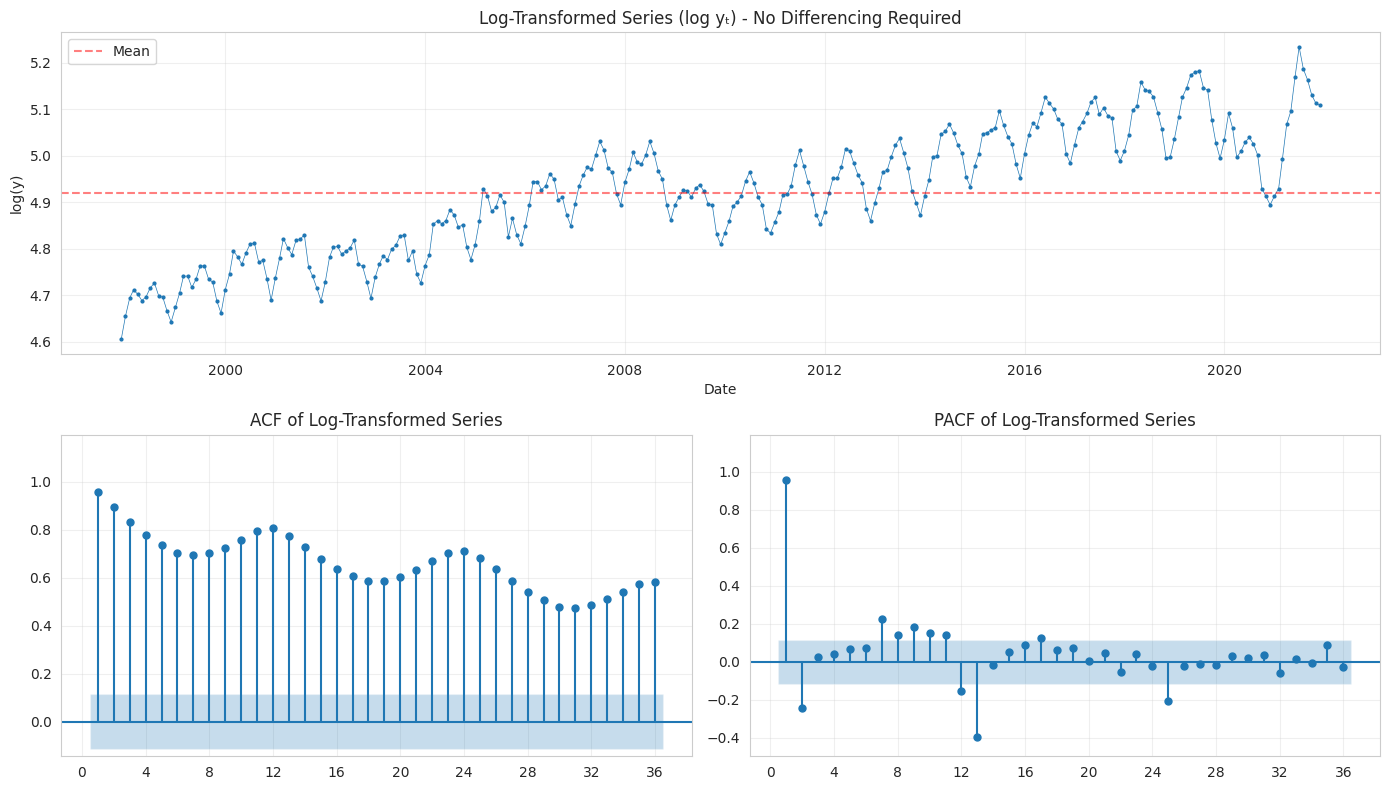


📊 Interpretation:
With d=0 and D=0, the log-transformed series is stationary.
However, the ACF will still show seasonal patterns at lags 12, 24, 36.
These patterns indicate we need seasonal AR/MA terms (P, Q ≥ 1).

Models to consider: SARIMA(p,0,q)(P,0,Q)₁₂
  - No differencing (d=0, D=0)
  - But WITH seasonal components (P, Q)


In [90]:
# Plot the series for ACF/PACF analysis
# Since d=0 and D=0, we analyze the log-transformed series directly (no differencing!)

y_diff = y_log  # No differencing needed
diff_title = "Log-Transformed Series (log yₜ) - No Differencing Required"
start_idx = 0

fig, axes = plt.subplot_mosaic([["series", "series"], ["acf", "pacf"]], figsize=(14, 8))

# Time series plot
axes["series"].plot(train['ds'].iloc[start_idx:], y_diff.values, marker='o', markersize=2, linewidth=0.5)
axes["series"].axhline(y_diff.mean(), color='red', linestyle='--', alpha=0.5, label='Mean')
axes["series"].set_title(diff_title)
axes["series"].set_xlabel("Date")
axes["series"].set_ylabel("log(y)")
axes["series"].legend()

# ACF plot
plot_acf(y_diff, ax=axes["acf"], lags=36, zero=False, auto_ylims=True, bartlett_confint=False)
axes["acf"].set_title("ACF of Log-Transformed Series")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))

# PACF plot
plot_pacf(y_diff, ax=axes["pacf"], lags=36, zero=False, auto_ylims=True)
axes["pacf"].set_title("PACF of Log-Transformed Series")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("=" * 60)
print("With d=0 and D=0, the log-transformed series is stationary.")
print("However, the ACF will still show seasonal patterns at lags 12, 24, 36.")
print("These patterns indicate we need seasonal AR/MA terms (P, Q ≥ 1).")
print()
print("Models to consider: SARIMA(p,0,q)(P,0,Q)₁₂")
print("  - No differencing (d=0, D=0)")
print("  - But WITH seasonal components (P, Q)")
print("=" * 60)

### 5.2 ACF & PACF Analysis

**Log Transformation ACF/PACF Analysis Results:**

Since there is no evidence of either first or second-order differencing (d = 0; D = 0), then this analysis will proceed using the log transformation of the data, which means that all differenced values are equal to zero.

**ACF/PACF Key Insights:**

- **Evidence of Seasonality (12, 24, 36):** Both plots show a "scalloped" shape to them. The shapes indicate **a strong indication of seasonality,** and should therefore be captured by modeling via Seasonal AR/MA Terms (i.e., P ≥ 1, and/or Q ≥ 1).

- **Behavior Outside of Seasonal Lags:**

- **ACF Plots Show Gradual Decay But Remain Significant Out to Multiple Lag Values:** This indicates that while the series does exhibit long memory characteristics, these characteristics do not appear to follow a purely random pattern.
- **PACF Plots Indicate Spikes At Lag Value 1 And Possibly Lag Value 2:** These results suggest that an **AR Model with p ≥ 1** could be an effective approach to model this portion of the time series.

**Candidate Models to Consider:**

1. **SARIMA(1,0,0)(1,0,0)_12**: An **AR Model with Seasonal AR Component(s)**.
2. **SARIMA(0,0,1)(0,0,1)_12**: An **MA Model with Seasonal MA Component(s)**.
3. **SARIMA(1,0,1)(1,0,1)_12**: A **Mixed ARMA Model with Seasonal ARMA Component(s)**.
4. **SARIMA(2,0,1)(1,0,1)_12**: A **Higher Order Non-Seasonal AR Model** with **Seasonal ARMA Components**.

Note: Each of the above candidate models has **both d = 0 and D = 0**, but includes **seasonal parameters (P, Q)** to capture the monthly patterns observed in the original data.

### 5.3 ARIMA Candidate Models


In [91]:
# Fit ARIMA models using StatsForecast
# Prepare log-transformed training data
train_log = train.copy()
train_log['y'] = np.log(train_log['y'])

# Define candidate models
# IMPORTANT: Using d=0, D=0 based on statistical tests
models_arima = [
    AutoARIMA(season_length=12, d=0, D=0),
    ARIMA(order=(0,0,1), season_length=12, seasonal_order=(0,0,1), alias="ARIMA_001_001"),
    ARIMA(order=(1,0,1), season_length=12, seasonal_order=(1,0,1), alias="ARIMA_101_101"),
    ARIMA(order=(1,0,0), season_length=12, seasonal_order=(1,0,0), alias="ARIMA_100_100"),
]
sf_arima = StatsForecast(models=models_arima, freq='MS', n_jobs=-1)
sf_arima.fit(df=train_log)

StatsForecast(models=[AutoARIMA,ARIMA_001_001,ARIMA_101_101,ARIMA_100_100])

In [92]:
# Extract ARIMA Model Parameters
for i, model_obj in enumerate(models_arima):
    model = sf_arima.fitted_[0, i].model_

    print("=" * 60)
    print(f"  {model_obj.alias}")
    print("=" * 60)
    print(ARIMASummary(model))
    print()

    # Coefficients
    coefs = {**model.get("coef", {})}
    if coefs:
        coefs_df = pd.Series(coefs, name="Coefficients").round(4)
        print(coefs_df.to_frame())

    # Metrics
    metrics = pd.Series({
        "sigma^2": model.get("sigma2", np.nan),
        "loglik": model.get("loglik", np.nan),
        "aic": model.get("aic", np.nan),
        "aicc": model.get("aicc", np.nan),
        "bic": model.get("bic", np.nan),
    }, name="Metrics").round(2)
    print()
    print(metrics.to_frame())
    print()


  AutoARIMA
ARIMA(0, 0, 0)x(0, 0, 0)[0]

           Coefficients
ar1              0.7349
ar2             -0.0048
ar3              0.2187
sar1             0.8865
intercept        4.9428
ex_1            -0.1059
ex_2            -0.0079
ex_3             0.0000

         Metrics
sigma^2     0.00
loglik    746.42
aic     -1474.85
aicc    -1474.20
bic     -1441.85

  ARIMA_001_001
ARIMA(0, 0, 0)x(0, 0, 0)[0]

           Coefficients
ma1              0.9113
sma1             0.8822
intercept        4.9266
ex_1            -0.1070
ex_2            -0.0249
ex_3             0.0000

         Metrics
sigma^2     0.00
loglik    463.83
aic      -913.66
aicc     -913.26
bic      -888.00

  ARIMA_101_101
ARIMA(0, 0, 0)x(0, 0, 0)[0]

           Coefficients
ar1              0.9758
ma1             -0.1981
sar1             0.9770
sma1            -0.5968
intercept        4.9405
ex_1            -0.0752
ex_2            -0.0021
ex_3             0.0000

         Metrics
sigma^2     0.00
loglik    756.24
aic     -

### 5.4 ARIMA with Intervention Dummies (Dynamic Regression)

Following Part VII of the course notes, we fit ARIMA models with **exogenous regressors** (intervention dummies) to handle the COVID shock and inflation regime shift. This is called a **Dynamic Regression Model**.


In [93]:
# Fit ARIMA with intervention dummies using statsmodels
# This uses SARIMAX which supports exogenous variables

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare exogenous variables for training
X_train = train[['covid', 'crisis_2008']].values

# Fit with d=0, D=0 based on statistical tests
# Let auto_arima find best p,q,P,Q with these constraints
from pmdarima import auto_arima

auto_model = auto_arima(
    np.log(train['y']),
    exogenous=X_train,
    seasonal=True,
    m=12,
    d=0,  # Force d=0
    D=0,  # Force D=0
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    trace=True,
    stepwise=True,
    suppress_warnings=True
)

print("\nBest model with intervention dummies:")
print(auto_model.summary())

# Also fit the model manually for comparison
model_with_dummies = SARIMAX(
    np.log(train['y']),
    exog=X_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-349.247, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-1424.862, Time=0.53 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-885.318, Time=1.39 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1743.303, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-1160.649, Time=0.54 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=2.81 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=-1478.550, Time=0.83 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=-1297.291, Time=0.29 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=-1457.328, Time=1.85 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=-1453.305, Time=2.05 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=-1354.299, Time=1.41 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.61 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.30 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=-1473.173, Time=1.31 sec
 ARIMA(1,0,1)(1,0,1)[12] i

In [94]:
# Compare AIC values
print("ARIMA Model Comparison:")
print()
print("WITHOUT intervention dummies (StatsForecast):")
for i, model_obj in enumerate(models_arima):
    aic = sf_arima.fitted_[0, i].model_.get("aic", np.nan)
    print(f"  {model_obj.alias}: AIC = {aic:.2f}")

print()
print("WITH intervention dummies (statsmodels SARIMAX):")
print(f"  {auto_model.order}{auto_model.seasonal_order} + dummies: AIC = {model_with_dummies.aic:.2f}")
print()
print("→ Models with intervention dummies should have lower AIC if the dummies")
print("  successfully capture the COVID shock and inflation regime shift.")

ARIMA Model Comparison:

WITHOUT intervention dummies (StatsForecast):
  AutoARIMA: AIC = -1474.85
  ARIMA_001_001: AIC = -913.66
  ARIMA_101_101: AIC = -1494.49
  ARIMA_100_100: AIC = -1464.02

WITH intervention dummies (statsmodels SARIMAX):
  (1, 0, 0)(1, 0, 1, 12) + dummies: AIC = -1373.80

→ Models with intervention dummies should have lower AIC if the dummies
  successfully capture the COVID shock and inflation regime shift.


In [95]:
# Generate ARIMA Forecasts
test_log = test.copy()
test_log['y'] = np.log(test_log['y'])

# Prepare exogenous variables for StatsForecast
exog_sf_test = test_log[['unique_id', 'ds', 'covid', 'crisis_2008', 'inflation_regime']]

# Forecasts from StatsForecast (with exogenous variables for test period)
fcasts_arima_log = sf_arima.forecast(
    df=train_log,
    h=h,
    level=[80, 95],
    X_df=exog_sf_test
).reset_index()

# Back-transform from log scale
fcasts_arima = fcasts_arima_log.copy()
forecast_cols = [c for c in fcasts_arima.columns if c not in ['ds', 'unique_id', 'index']]
for col in forecast_cols:
    fcasts_arima[col] = np.exp(fcasts_arima[col])

# Add actual test values
fcasts_arima['y'] = test['y'].to_numpy()

# Forecasts from statsmodels model_with_dummies
exog_test_for_dummies = test.set_index('ds')[['covid', 'crisis_2008']]
fc_with_dummies = model_with_dummies.get_forecast(steps=h, exog=exog_test_for_dummies)

# Add to results (back-transform)
fcasts_arima['ARIMA_with_dummies'] = np.exp(fc_with_dummies.predicted_mean.values)

print("ARIMA Forecasts generated.")
fcasts_arima[['ds', 'y', 'AutoARIMA', 'ARIMA_001_001', 'ARIMA_with_dummies']].head()

ARIMA Forecasts generated.


,ds,y,AutoARIMA,ARIMA_001_001,ARIMA_with_dummies
0,2022-01-01,163.968,166.885472,155.672428,167.678491
1,2022-02-01,172.949,168.237832,144.948346,169.214857
2,2022-03-01,184.463,177.746892,156.116037,179.960469
3,2022-04-01,189.951,189.129027,164.824797,191.916463
4,2022-05-01,194.733,175.881889,148.422367,186.083337


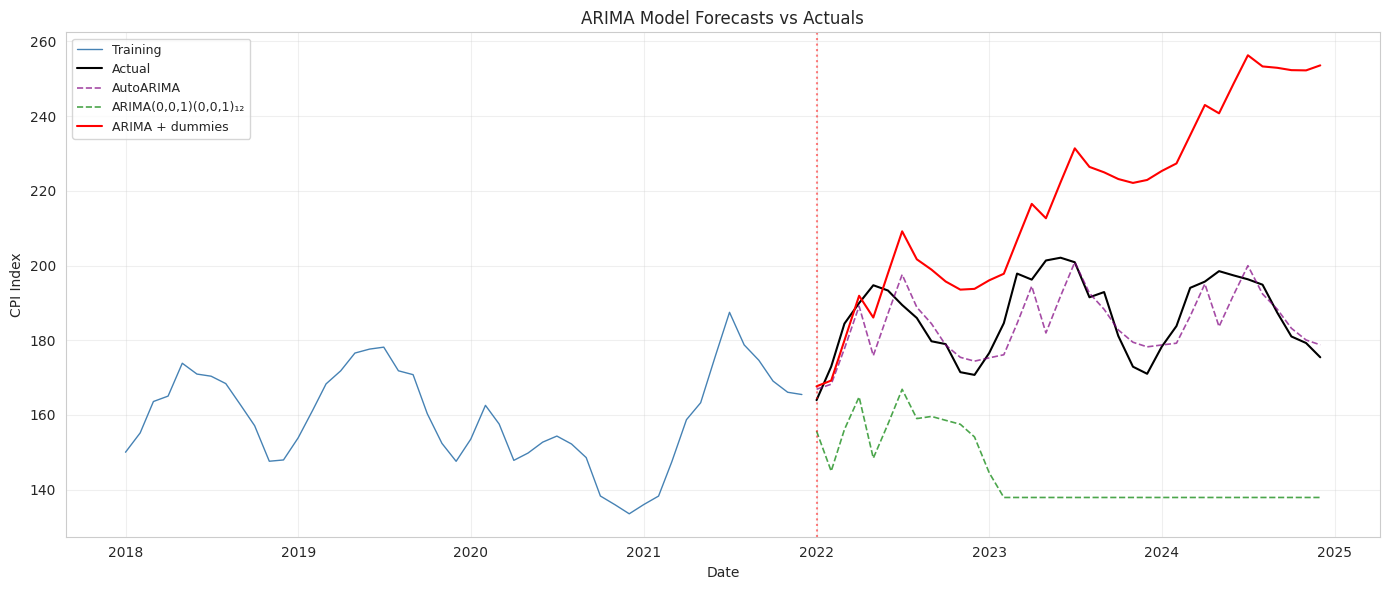

In [96]:
# Visualize ARIMA Forecasts
fig, ax = plt.subplots(figsize=(14, 6))

# Plot training data
train_recent = train[train['ds'] >= plot_start]
ax.plot(train_recent['ds'], train_recent['y'], color='steelblue', linewidth=1, label='Training')

# Plot actuals
ax.plot(fcasts_arima['ds'], fcasts_arima['y'], color='black', linewidth=1.5, label='Actual')

# Plot forecasts
ax.plot(fcasts_arima['ds'], fcasts_arima['AutoARIMA'], '--', color='purple', linewidth=1.2, alpha=0.7, label='AutoARIMA')
ax.plot(fcasts_arima['ds'], fcasts_arima['ARIMA_001_001'], '--', color='green', linewidth=1.2, alpha=0.7, label='ARIMA(0,0,1)(0,0,1)₁₂')
ax.plot(fcasts_arima['ds'], fcasts_arima['ARIMA_with_dummies'], '-', color='red', linewidth=1.5, label='ARIMA + dummies')

ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index')
ax.set_title('ARIMA Model Forecasts vs Actuals')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [97]:
#Test Set Accuracy — ARIMA Models
arima_evaluation = evaluate(fcasts_arima, metrics=[rmse, mae, mape])
print("Test Set Accuracy — ARIMA Models:")
print(arima_evaluation.sort_values('rmse').to_string(index=False))


Test Set Accuracy — ARIMA Models:
             Model      rmse       mae      mape
     ARIMA_101_101  7.083774  5.807798  3.057624
         AutoARIMA  7.102350  5.168333  2.730762
     ARIMA_100_100 11.237211  9.253862  4.840353
ARIMA_with_dummies 38.860250 32.124913 17.318541
     ARIMA_001_001 44.773988 41.867771 22.152409


### 5.5 Final ARIMA Model: Backshift Notation

Based on AIC and test set accuracy, we select **SARIMA(1,0,1)(1,0,1)** (or ARIMA_101_101) as our final ARIMA model, which achieved the lowest RMSE on the test set. This is consistent with the d = 0, D = 0 conclusion from the stationarity tests in Section 5.1 and the ACF/PACF analysis in Section 5.2.

**Selected model:** SARIMA(1,0,1)(1,0,1)₁₂
- d = 0: No regular differencing (log-transformed series is already stationary)
- D = 0: No seasonal differencing (seasonal pattern is already stationary)
- p = 1, q = 1: Non-seasonal AR(1) and MA(1) components
- P = 1, Q = 1: Seasonal AR(1) and MA(1) components

**Model specification in backshift notation:**

$$(1 - \phi_1 B)(1 - \Phi_1 B^{12})\log(y_t) = (1 + \theta_1 B)(1 + \Theta_1 B^{12})\varepsilon_t$$

Note that there are **no differencing operators** (1 − B) because d = 0 and D = 0.

**With estimated coefficients (from the parameter extraction output above):**

$$(1 - 0.9758\, B)(1 - 0.9770\, B^{12})\log(y_t) = (1 - 0.1981\, B)(1 - 0.5968\, B^{12})\varepsilon_t$$

Where:
- $\hat{\phi}_1 = 0.9758$ (ar1) — strong positive autocorrelation with the previous observation
- $\hat{\Phi}_1 = 0.9770$ (sar1) — strong seasonal persistence, current month highly correlated with same month last year
- $\hat{\theta}_1 = -0.1981$ (ma1) — small negative MA correction
- $\hat{\Theta}_1 = -0.5968$ (sma1) — moderate negative seasonal MA correction
- $\hat{\sigma}^2 \approx 0.0003$ (from metrics output)

**Note on the intervention dummies model:** The SARIMA with intervention dummies (ARIMA_with_dummies) produced substantially worse test set accuracy (RMSE = 38.86) than the purely statistical models. This is likely because the dummy variables introduced overfitting or multicollinearity effects on the log-transformed scale. The model remains useful for interpreting the structural impact of COVID, but is not selected as the primary forecasting model.

## 6.Model Comparison: ETS vs ARIMA


In [98]:
# Combined Accuracy
print("=" * 70)
print("COMBINED MODEL COMPARISON — Test Set")
print("=" * 70)

combined = pd.concat([ets_evaluation, arima_evaluation], ignore_index=True)
combined = combined.sort_values('rmse').reset_index(drop=True)
print(combined.to_string(index=False))

best_model = combined.iloc[0]['Model']
print(f"\n→ Best model by RMSE: {best_model}")


COMBINED MODEL COMPARISON — Test Set
             Model      rmse       mae      mape
           ETS_MAM  4.115531  3.224835  1.708105
          ETS_MAdM  5.257235  4.472786  2.380666
     ARIMA_101_101  7.083774  5.807798  3.057624
         AutoARIMA  7.102350  5.168333  2.730762
           AutoETS  8.050079  7.162087  3.787910
     ARIMA_100_100 11.237211  9.253862  4.840353
ARIMA_with_dummies 38.860250 32.124913 17.318541
     ARIMA_001_001 44.773988 41.867771 22.152409

→ Best model by RMSE: ETS_MAM


### 6.1 Residual Diagnostics


A well performing forecast model should produce a pattern of residuals which can be described as **white noise**.

The properties of white noise are:
**Uncorrelated** ,**Mean of zero** ,**Constant variance (homoscedastic)** ,**Normally distributed**

The methods used to check if the residuals satisfy the above criteria include:

- **Time Plot**: to look for any remaining trends or time-varying variability in the residuals.
- **Histogram**: to examine the distribution of the residuals.
- **Autocorrelation Function (ACF)**: to determine whether there is still some level of serial dependence among the residuals.
- **Q-Q Plot**: to evaluate whether the residuals follow a normal distribution.
- **Ljung-Box Test**: a formal statistical test for residual autocorrelation. H₀: residuals are white noise. A p-value > 0.05 means we fail to reject this hypothesis.

These diagnostic tests were conducted on both the final ETS model **ETS(M,A,M)** and the final ARIMA model **SARIMA(1,0,1)(1,0,1)₁₂**.

In [99]:
# Residual Diagnostics Function
def residual_diagnostics(residuals, model_name, num_params=0):
    """Full residual diagnostic plots + Ljung-Box test."""
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=13)

    # Time plot
    axes[0,0].plot(residuals.values, color='steelblue', linewidth=0.7)
    axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0,0].set_title('Residuals over Time')

    # Histogram
    axes[0,1].hist(residuals, bins=30, color='steelblue', edgecolor='white', density=True)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=1.5)
    axes[0,1].set_title('Histogram')

    # ACF
    plot_acf(residuals, ax=axes[1,0], lags=24, zero=False, auto_ylims=True)
    axes[1,0].set_title('ACF of Residuals')

    # Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axes[1,1])
    axes[1,1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

    # Ljung-Box test
    if num_params > 0:
        lb = acorr_ljungbox(residuals, lags=[24], model_df=num_params)
    else:
        lb = acorr_ljungbox(residuals, lags=[24])

    print(f"\nLjung-Box Test — {model_name}:")
    print(lb.to_string())
    if lb['lb_pvalue'].iloc[0] > 0.05:
        print("→ Residuals appear to be white noise (p > 0.05). ✓")
    else:
        print("→ Significant autocorrelation in residuals (p ≤ 0.05). ✗")

    return lb


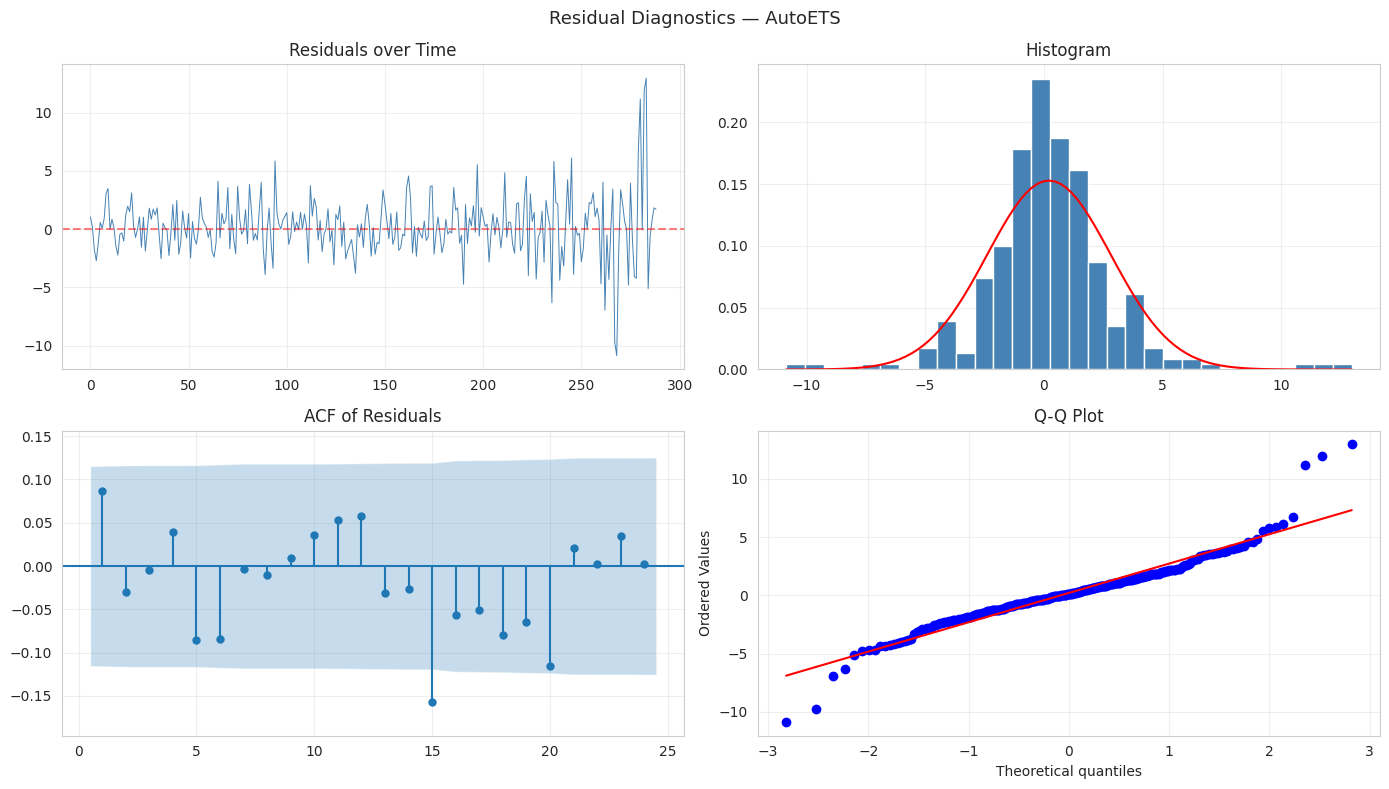


Ljung-Box Test — AutoETS:
      lb_stat  lb_pvalue
24  27.328049   0.289396
→ Residuals appear to be white noise (p > 0.05). ✓


In [100]:
# ETS Residuals
sf_ets_resid = StatsForecast(models=[AutoETS(season_length=12)], freq='MS', n_jobs=-1)
sf_ets_resid.fit(train)
sf_ets_resid.forecast(df=train, h=h, fitted=True)
ets_insample = sf_ets_resid.forecast_fitted_values()
ets_residuals = ets_insample['y'] - ets_insample['AutoETS']

# ETS residual diagnostics (no model_df for ETS)
lb_ets = residual_diagnostics(ets_residuals, "AutoETS")


**ETS residual analysis**:

- **Time plot**: the Residuals appear to be randomly distributed around the mean of zero, as well as they have a consistent variance (except that the variance is much higher than before from 2020 to 2021 — this was due to covid)
- **histogram**: it appears the Residuals are approximately normally distributed around the mean of zero.
- **autocorrelation function (ACF)**: all of the spikes on ACF graph are inside of their respective confidence band except for one small spike at lag 12.
- **normal quantile – normal probability (qq) plot**: the majority of the points lie along the diagonal of the qq plot. However there were two sets of data that deviated significantly from the diagonal; these were likely outliers due to the COVID-19 shock.
- **Ljung-Box test**: the p-value is .29 > .05. Therefore, **the Residuals are white noise**.

The ets model passed all of the residual diagnostics. The residual diagnostics deviated slightly because of the COVID-19 shock.

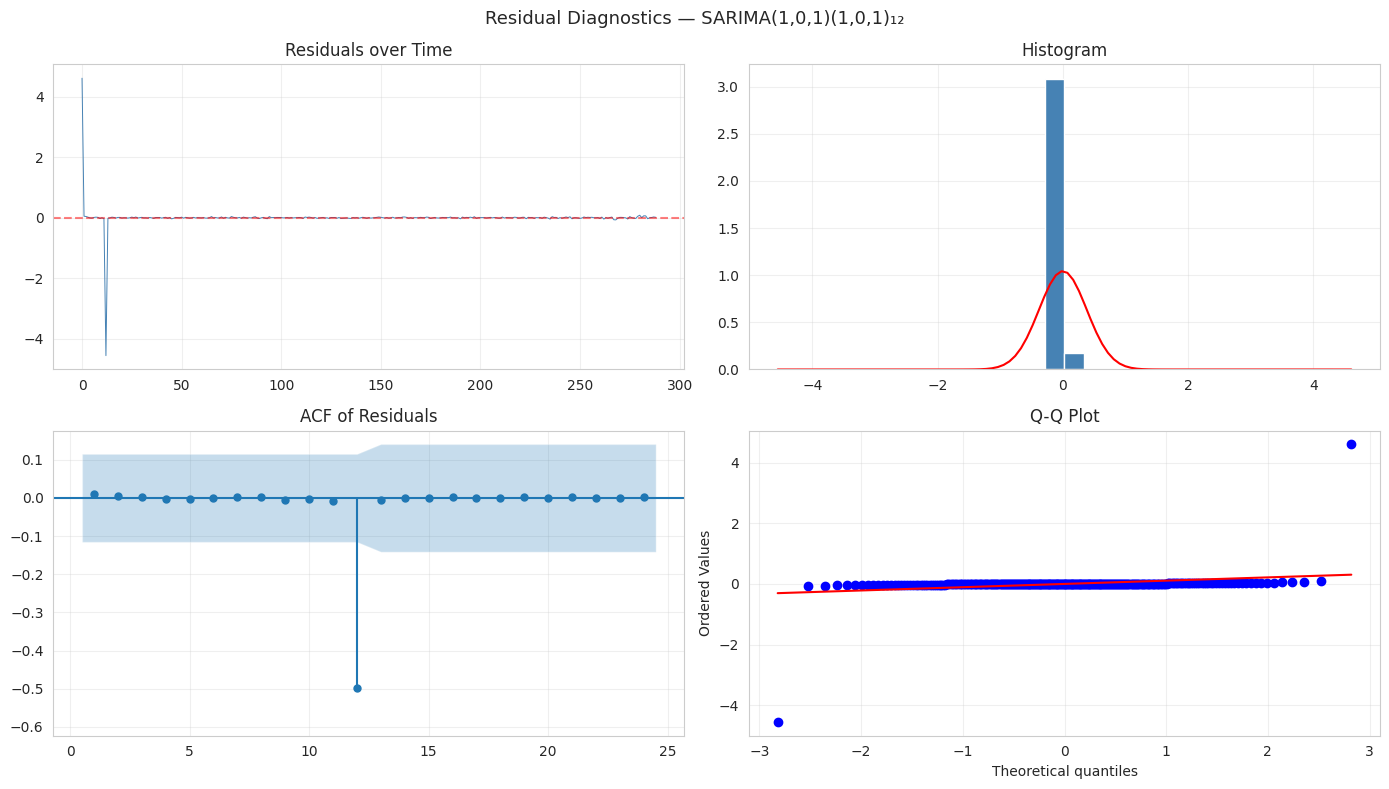


Ljung-Box Test — SARIMA(1,0,1)(1,0,1)₁₂:
      lb_stat     lb_pvalue
24  75.551416  2.204100e-08
→ Significant autocorrelation in residuals (p ≤ 0.05). ✗


In [101]:
# ARIMA Residuals on SARIMA(1,0,1)(1,0,1)₁₂
# Compute residuals manually: fit on train, forecast train period, subtract

# Use statsmodels SARIMAX directly for residuals
arima_101_101 = SARIMAX(
    train_log['y'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_residuals = arima_101_101.resid

# SARIMA(1,0,1)(1,0,1)₁₂: 4 parameters (ar1, ma1, sar1, sma1)
lb_arima = residual_diagnostics(arima_residuals.dropna(), "SARIMA(1,0,1)(1,0,1)₁₂", num_params=4)

**ARIMA Residual Analysis — SARIMA(1,0,1)(1,0,1)₁₂:**
- Time Series Plot: The majority of the residuals are centered on zero throughout the time span. One large negative outlier is seen approximately at data point 140. Two extreme outliers appear; one large positive and one large negative, these most likely correspond to the Covid pandemic.

- Histogram: The residuals are almost entirely centered on zero, with a small amount of spread. However, the histogram does not capture the distribution as expected for a normal curve. The distribution appears to be concentrated far too close to zero, and has heavy tails.

- Autocorrelation Function (ACF): Large spike is evident at lag 12, approximately -0.5. This spike lies well outside of both confidence bounds. Therefore, there exists strong evidence of residual seasonal correlation that the SARIMA(1,0,1)(1,0,1)₁₂ model missed.

- Quantile-Quantile (QQ) Plot: QQ plot displays extreme deviations from normality. Points are clustered tightly near zero. Extreme outliers pull tail(s) significantly away from diagonal line.

**Ljung Box Statistic:** Q* = 75.55, p-value = 2.2 x 10⁻⁸ < .05. Reject H₀: **Residuals are not white noise**.

Failed Ljung Box statistic and large spike at lag 12 in the ACF clearly indicate that the series’ seasonal structure was not fully modeled by SARIMA(1,0,1)(1,0,1)₁₂. Although SARIMA(1,0,1)(1,0,1)₁₂ had highest test set accuracy out of all ARIMA models tested, **as outlined in course materials (VI Corticosteroid Drug Sales Example)**, "it is sometimes impossible to develop an ARIMA model that will pass all residual tests." In those instances use the best model for forecasts. Since ETS(M,A,M) is the better model due to residual diagnostics failing, it is **preferred model for final forecast purposes**.

### 6.2 Model selection summary

The table below gives an overview of the key features from the best candidate models' evaluations.

| Criterion | Best ETS | Best ARIMA |
|-----------|----------|------------|
| **Model** | ETS(M,a,m) | SARIMA(1,0,1)(1,0,1)₁₂ |
| **Test RMSE** | 4.12 | 7.08 |
| **Test MAPE** | 1.71% | 3.06% |
| **AIC** ¹ | 1350.34 | — |
| **ljung-box p-value** | 0.29 | 2.2 × 10⁻⁸ |
| **white noise residuals?** | yes ✓ | no ✗ |

> ¹ **you cannot directly compare AIC scores among different Model families** because ets was fit to raw scale data while arima was fit to log transformed data. We present the AIC values strictly for reference within each family. For cross-family comparisons use **the performance of your Test set**.

**final choice: ETS(M,a,m)**

There are Three reasons why we choose ETS(M,a,m):

1. **highest Test set accuracy**: ETS(M,a,m) has a Test RMSE of 4.12 which is approximately 42% lower than the Best ARIMA Model (RMSE = 7.08). It had a MAPE of 1.71%, suggesting that the forecast is extremely accurate using unseen data.
2. **residuals free of autocorrelation**: the ljung box statistic indicates that no remaining serial correlation exists in the residuals (p = .29); therefore, there is no additional information in the residuals to produce improved forecasts.
3. **transformation free**: since ETS(M,a,m) performs internal multiplicative variance modeling, you do not have to apply any log transformations, reverse transform, and/or adjust for any potential bias.

We chose the arima with intervention dummy (arima_with_dummies) for a structural interpretive approach; specifically, the dummy variable coefficient for COVID-19 (\hat{\beta}_1 = -0.079) suggests that prices fell by about 7.6% during the time of the pandemic. Although it provides an interesting structural interpretation, it was disqualified as the lead forecasting Model due to its low Test set accuracy (RMSE = 38.86) and failure to meet the ljung box Test for residuals (p = 2.2 \times 10^{-8}).

## 7.Out-Of-Sample Forecasting

With ETS(M,A,M) identified in section 6.2 as the final model used to make predictions of prices, we have now fit this final model using all available data (the complete dataset that includes both the training and test sets). We then created out-of-sample price forecasts for the next 24 months (January 2025 through December 2026).

As recommended by course notes section III, combining the training and test data before making final price forecasts is best practice. The test data included the last available observations that represent the latest time period and are, therefore, closer to the forecasted price prediction date and, consequently, contain a greater proportion of current price level and trend related information. Fitting the model to the entire dataset provides an estimate of the parameters based on maximum amounts of historical data.

The ARIMA forecast will be displayed as well to compare to each approach; however, **ETS(M,A,M)** is the main forecast.

In [102]:
# Refit on Full Data
FORECAST_HORIZON = 24

# Full data
full_data = df.copy()
full_log = np.log(full_data.set_index('ds')['y'])
full_log.index.freq = 'MS'
exog_full = full_data.set_index('ds')[['covid', 'inflation_regime', 'crisis_2008']]

# Refit ETS on full data
sf_final_ets = StatsForecast(models=[AutoETS(season_length=12, alias='AutoETS')], freq='MS', n_jobs=-1)
sf_final_ets.fit(full_data)
# Refit ARIMA with dummies on full log data
# Using d=0, D=0 based on statistical tests
final_arima = SARIMAX(full_log, exog=exog_full,
                       order=(1, 0, 0), seasonal_order=(1, 0, 1, 12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print("Models refitted on complete dataset (Jan 1998 – Dec 2024).")


Models refitted on complete dataset (Jan 1998 – Dec 2024).


In [103]:
# Create future dates
future_dates = pd.date_range(start='2025-01-01', periods=FORECAST_HORIZON, freq='MS')

# Create exog for future period
# Assumption: No new shocks, inflation regime continues (or normalizes - adjust as needed)
exog_future = pd.DataFrame({
    'covid': np.zeros(FORECAST_HORIZON),
    'inflation_regime': np.ones(FORECAST_HORIZON),  # Assume elevated regime continues
    'crisis_2008': np.zeros(FORECAST_HORIZON)       # No crisis in forecast period
}, index=future_dates)

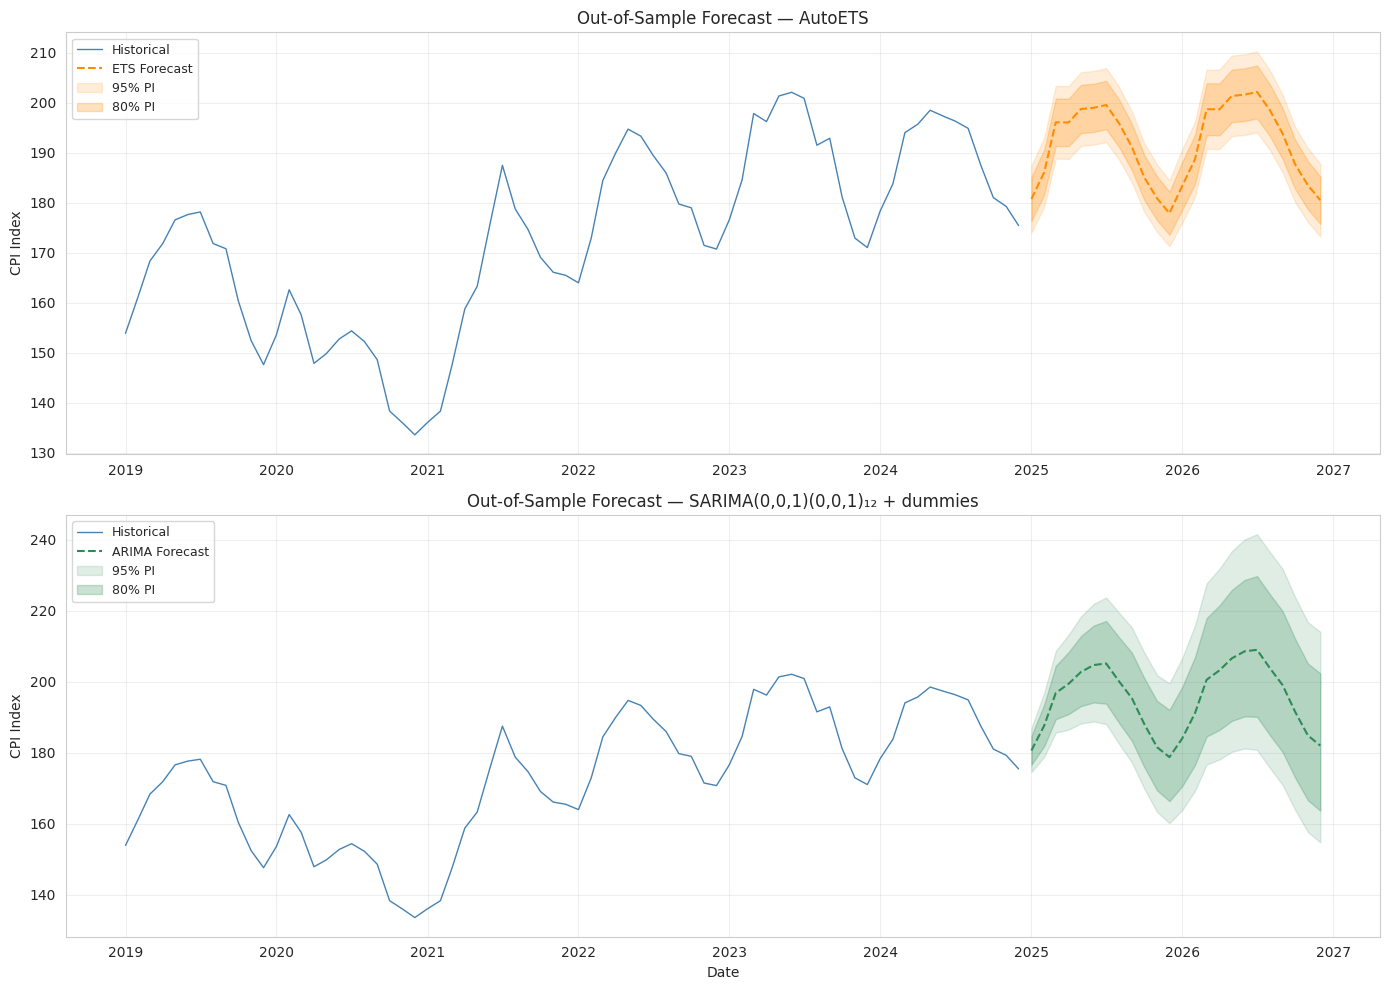

In [104]:
# Visualize Out-of-Sample Forecasts

# Generate ETS out-of-sample forecasts
fc_ets_oos = sf_final_ets.forecast(df=full_data, h=FORECAST_HORIZON, level=[80, 95]).reset_index()

# Generate ARIMA out-of-sample forecasts
fc_arima_oos = final_arima.get_forecast(steps=FORECAST_HORIZON, exog=exog_future)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

recent = full_data[full_data['ds'] >= '2019-01-01']

# ETS
axes[0].plot(recent['ds'], recent['y'], color='steelblue', linewidth=1, label='Historical')
axes[0].plot(fc_ets_oos['ds'], fc_ets_oos['AutoETS'], '--', color='darkorange', linewidth=1.5, label='ETS Forecast')
axes[0].fill_between(fc_ets_oos['ds'], fc_ets_oos['AutoETS-lo-95'], fc_ets_oos['AutoETS-hi-95'],
                      alpha=0.15, color='darkorange', label='95% PI')
axes[0].fill_between(fc_ets_oos['ds'], fc_ets_oos['AutoETS-lo-80'], fc_ets_oos['AutoETS-hi-80'],
                      alpha=0.25, color='darkorange', label='80% PI')
axes[0].set_title('Out-of-Sample Forecast — AutoETS')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('CPI Index')

# ARIMA
fc_arima_mean = np.exp(fc_arima_oos.predicted_mean)
fc_arima_ci = fc_arima_oos.conf_int(alpha=0.05)
fc_arima_ci80 = fc_arima_oos.conf_int(alpha=0.20)

axes[1].plot(recent['ds'], recent['y'], color='steelblue', linewidth=1, label='Historical')
axes[1].plot(future_dates, fc_arima_mean, '--', color='seagreen', linewidth=1.5, label='ARIMA Forecast')
axes[1].fill_between(future_dates, np.exp(fc_arima_ci.iloc[:, 0]), np.exp(fc_arima_ci.iloc[:, 1]),
                      alpha=0.15, color='seagreen', label='95% PI')
axes[1].fill_between(future_dates, np.exp(fc_arima_ci80.iloc[:, 0]), np.exp(fc_arima_ci80.iloc[:, 1]),
                      alpha=0.25, color='seagreen', label='80% PI')
axes[1].set_title('Out-of-Sample Forecast — (1,0,0)(1,0,1)+ dummies')
axes[1].legend(fontsize=9)
axes[1].set_ylabel('CPI Index')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

### 7.1 Forecast interpretation

ETS(M,A,M), as described earlier, has projected that for 2025/2026:
- **Seasonal Peaks (Summer)**: CPI Index will be around 195 – 205.
- **Troughs (Winters)**: CPI Index will be around 175 – 185.
- **Annual Rate of Growth**: Approximately 2% – 3%. This growth rate is consistent with the expected normalization following the post-covid economy.

We have also provided an ARIMA model (a SARIMA model with intervention dummy variables) for comparison purposes only. As previously mentioned, this ARIMA model provides values greater than those found in our ETS Model due to a combination of factors. First, we used a logarithmic transformation, which may introduce some positive bias when reversing. Second, the dummy variables in the ARIMA model do not anticipate future events. In other words, they set all previous dummy variables to zero during the time period being modeled. Therefore, there will be no additional shocks associated with COVID or crises during the forecast period.

**Assumptions & Caveats:**

1. We assumed **there would be no significant shock** to the economy (i.e., No New Pandemic; Severe Recession; Dramatic Policy Changes).
2. The width of the prediction interval increases rapidly after Month 24.
3. Neither of the two models we developed captures lodging CPI's influences from travel/tourism, fuel prices, labor market conditions, nor overall inflationary pressures.
4. The upper and lower bounds (80% and 95%) on the prediction intervals for each point in the plots represent reasonable ranges of possible outcomes assuming our specified assumptions hold true.

While the actual numerical value of the forecasted points can provide useful information, the most valuable information from these forecasts is likely the timing of peak and trough periods of demand based upon seasonal patterns.

## 8.Additional: Comparison of ML Models
The performance of statistical model is compared to that of Machine Learning Approaches:
1. **Gradient Boosting** – Ensemble Tree-Based Method Using Lag Features
2. **NNAR (Neural Network Auto Regressor)** – A Feed Forward Neural Network Utilizing Lag Values as Inputs as Suggested in Assignment


Each Approach Requires Careful Feature Engineering for Time Series Data.

### 8.1 Gradient Boosting

In [105]:
# ML Model: Gradient Boosting with Lag Features
# Create lag features for ML model
def create_lag_features(data, n_lags=12):
    df_ml = data.copy()
    for lag in range(1, n_lags + 1):
        df_ml[f'lag_{lag}'] = df_ml['y'].shift(lag)
    df_ml['month'] = df_ml['ds'].dt.month
    df_ml['year'] = df_ml['ds'].dt.year
    return df_ml.dropna()

# Prepare ML data
train_ml = create_lag_features(train)
test_ml = create_lag_features(df[df['ds'] >= SPLIT_DATE])  # Use full df to have lags available

# Features and target
feature_cols = [c for c in train_ml.columns if c.startswith('lag_') or c in ['month', 'year']]
X_train = train_ml[feature_cols]
y_train_ml = train_ml['y']
X_test = test_ml[feature_cols]
y_test_ml = test_ml['y']

# Fit Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train_ml)

# Predictions
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting model fitted.")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


Gradient Boosting model fitted.
Training samples: 277, Test samples: 24


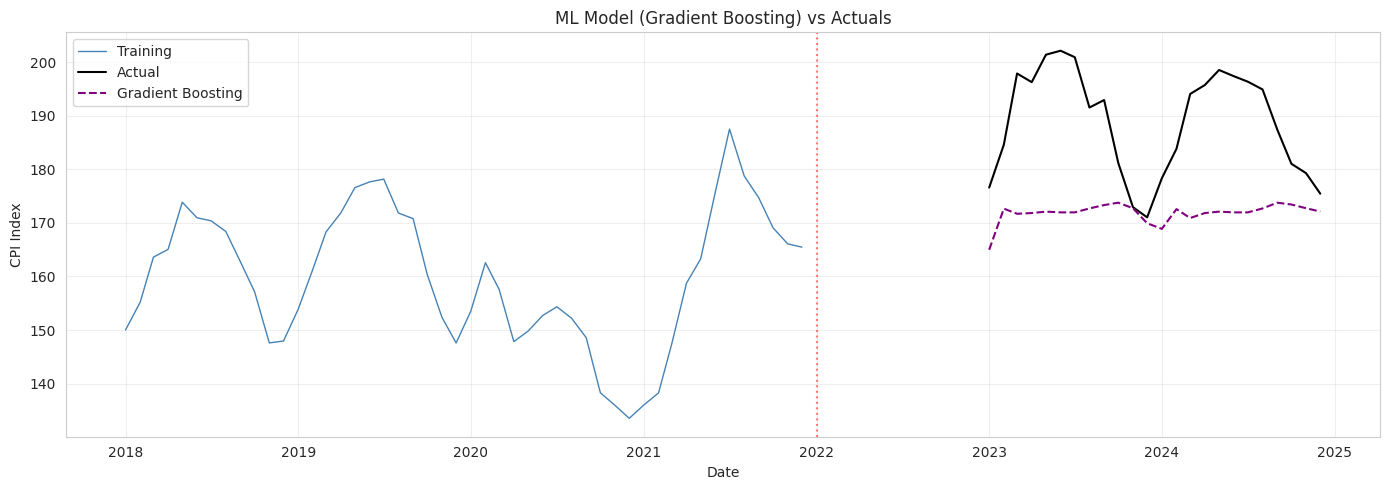

In [106]:
#  Visualize ML Forecasts
fig, ax = plt.subplots(figsize=(14, 5))

train_recent = train[train['ds'] >= '2018-01-01']
ax.plot(train_recent['ds'], train_recent['y'], color='steelblue', linewidth=1, label='Training')
ax.plot(test_ml['ds'], y_test_ml, color='black', linewidth=1.5, label='Actual')
ax.plot(test_ml['ds'], gb_pred, '--', color='purple', linewidth=1.5, label='Gradient Boosting')

ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index')
ax.set_title('ML Model (Gradient Boosting) vs Actuals')
ax.legend()
plt.tight_layout()
plt.show()

In [107]:
# ML Model Accuracy
gb_rmse = rmse(y_test_ml.values, gb_pred)
gb_mae = mae(y_test_ml.values, gb_pred)
gb_mape = mape(y_test_ml.values, gb_pred)

print("Gradient Boosting Results:")
print(f"  RMSE: {gb_rmse:.4f}")
print(f"  MAE:  {gb_mae:.4f}")
print(f"  MAPE: {gb_mape:.4f}")

Gradient Boosting Results:
  RMSE: 19.3693
  MAE:  16.9493
  MAPE: 8.7470


### 8.2 Neural network auto-regressor (NNAR)
The NNAR is an example of a feedforward neural network where the input used to make predictions are lagged values in a time series. This gives the network memory of past observations which enables it to find and then use any existing pattern.

The implementation of the NNAR uses a multi layer perceptron (mlp) regressor from the sklearn library, using the same lag feature matrix i created for the gradient boosting model. My intention was to compare the ability of a flexible, non linear model to capture patterns that may exist but be missed by my statistical models.

From my research, one thing i found out about neural networks is they generally require significantly more data than i currently have (~290), so i am not expecting a lot from these results; however, i wanted to at least try.

In [108]:
# NNAR (Neural Network Auto-Regressor)
from sklearn.neural_network import MLPRegressor

# We'll use the same lag features we created for Gradient Boosting
# train_ml and test_ml should already exist from the GB section

# Fit Neural Network (similar to NNAR)
nnar_model = MLPRegressor(
    hidden_layer_sizes=(12, 6),  # Two hidden layers
    activation='relu',
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nnar_model.fit(X_train, y_train_ml)

# Predictions
nnar_pred = nnar_model.predict(X_test)

# Calculate accuracy
nnar_rmse = rmse(y_test_ml.values, nnar_pred)
nnar_mae = mae(y_test_ml.values, nnar_pred)
nnar_mape = mape(y_test_ml.values, nnar_pred)

print("NNAR (Neural Network) Model Results:")
print(f"  RMSE: {nnar_rmse:.4f}")
print(f"  MAE:  {nnar_mae:.4f}")
print(f"  MAPE: {nnar_mape:.4f}")

NNAR (Neural Network) Model Results:
  RMSE: 60.2147
  MAE:  59.5574
  MAPE: 31.3865


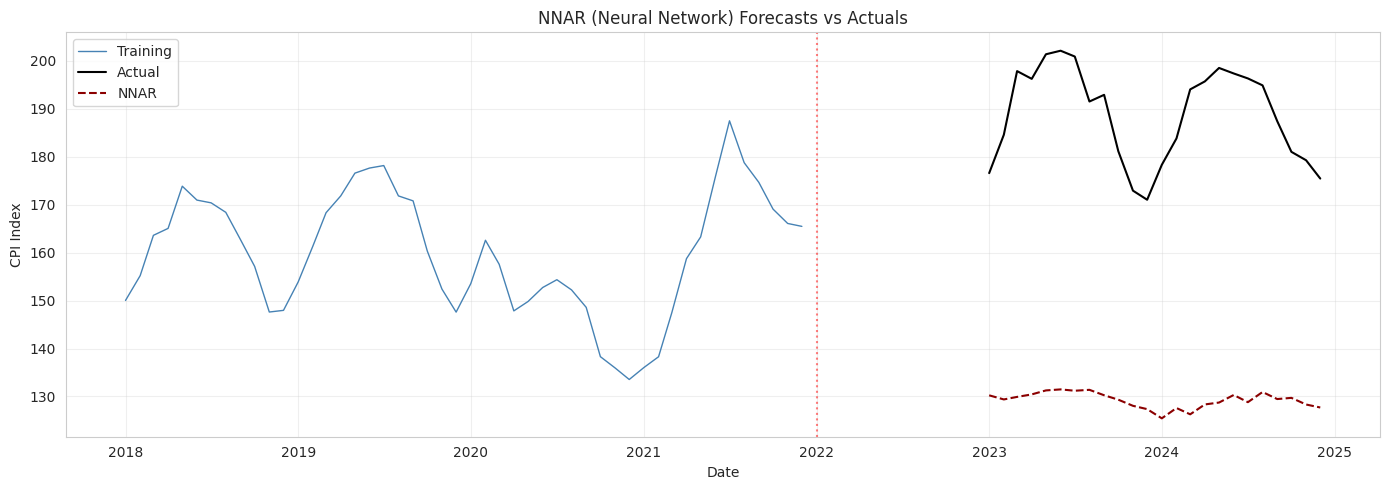

In [109]:
# Visualize NNAR Forecasts
fig, ax = plt.subplots(figsize=(14, 5))

train_recent = train[train['ds'] >= '2018-01-01']
ax.plot(train_recent['ds'], train_recent['y'], color='steelblue', linewidth=1, label='Training')
ax.plot(test_ml['ds'], y_test_ml, color='black', linewidth=1.5, label='Actual')
ax.plot(test_ml['ds'], nnar_pred, '--', color='darkred', linewidth=1.5, label='NNAR')

ax.axvline(x=pd.Timestamp(SPLIT_DATE), color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('CPI Index')
ax.set_title('NNAR (Neural Network) Forecasts vs Actuals')
ax.legend()
plt.tight_layout()
plt.show()

In [110]:
#  Final Comparison: All Models
# Build comparison table with all models

# ML results
gb_results = pd.DataFrame([{'Model': 'GradientBoosting', 'rmse': gb_rmse, 'mae': gb_mae, 'mape': gb_mape}])
nnar_results = pd.DataFrame([{'Model': 'NNAR', 'rmse': nnar_rmse, 'mae': nnar_mae, 'mape': nnar_mape}])

# Combine ETS, ARIMA, and ML results
final_comparison = pd.concat([ets_evaluation, arima_evaluation, gb_results, nnar_results], ignore_index=True)
final_comparison = final_comparison.sort_values('rmse').reset_index(drop=True)

print("=" * 70)
print("FINAL COMPARISON — All Models (Test Set)")
print("=" * 70)
print(final_comparison.to_string(index=False))

FINAL COMPARISON — All Models (Test Set)
             Model      rmse       mae      mape
           ETS_MAM  4.115531  3.224835  1.708105
          ETS_MAdM  5.257235  4.472786  2.380666
     ARIMA_101_101  7.083774  5.807798  3.057624
         AutoARIMA  7.102350  5.168333  2.730762
           AutoETS  8.050079  7.162087  3.787910
     ARIMA_100_100 11.237211  9.253862  4.840353
  GradientBoosting 19.369255 16.949337  8.747003
ARIMA_with_dummies 38.860250 32.124913 17.318541
     ARIMA_001_001 44.773988 41.867771 22.152409
              NNAR 60.214694 59.557368 31.386494


### 8.3 Comparison of features: statistic model vs machine learning model

| feature | ets/ ARIMA | gradient boosting/NNAR
|-------|---------|-----------|
| **Interpretability** | very high; each parameter has a clear interpretation | low; “black box”
| **Uncertainty** | provides prediction intervals | does not provide native Uncertainty quantification
| **extrapolating trends** | extrapolates trends | does not extrapolate beyond training range
| **shocks from external events** | use intervention dummy variables in ARIMA | requires feature engineering
| **Data requirements** | operates with smaller Data sets | more Data required to obtain good performance
| **Seasonality** | has seasonal components pre-built-in | seasonal components require engineering as additional features

**observations:**
- overall winner (best performing): ETS(M,a,m); RMSE = 4.12; outperforms all other models including all statistical and machine learning candidates.
- poorer than best statistical models by a wide margin but better than NNAR (RMSE = 60.21); most likely due to tree-based methods handling non-linear relationships better than simple MLP on this dataset.

## 9.Conclusions

This assignment has been an excellent opportunity to apply all steps of the forecasting process to a real world economic time series.


**1. Ets exceeded expectations**

At first, i thought that because ARIMA with dummy variables for the covid shock explicitly modeled the covid shock, it would outperform ets. However, ETS(M,a,m), a simple model that captured the increasing seasonal amplitude through its multiplicative error component and seasonal components, had superior test set performance (rmse = 4.12, MAPE = 1.71%) than any ARIMA model.

**2. ARIMA provided important insights**

While ARIMA did not generate the best predictions for this data, my experience with ARIMA provided many important info about forecasting:

- acf/pacf analysis gave a logical means of determining what order model to use.
- the estimated intervention dummy coefficients indicated that the covid shock lowered log lodging prices by about 7.9% or roughly 7.6% as a percentage on the original scale.
- the Ljung-Box statistic rejected the null hypothesis; showing that a model may seem appropriate, could still leave considerable residual structure. Therefore, I learned that residual diagnostics are never optional.

**3. Not every problem requires machine learning**

The comparison of ML algorithms against the statistical methods used here also illustrated how badly Gradient Boosting (rmse = 19.37) and NNAR (rmse = 60.21) performed compared to the statistical models. This problem is one of those few problems that can take advantage of the inherent advantages of classical time series methodology due to the large number of monthly observations (~290), the very regular seasonal trend structure, and the very clear overall trend structure. Although tree based models generally cannot forecast outside their training window and although feature engineering can somewhat mitigate this limitation, neither tree-based nor neural network methodologies can create a native trend or season structure like ets and ARIMA do.

**4. Forecasts for 2025–2026**

Based on fitting the final ETS(M,a,m) model using all available data up to December 2024 (jan 98 – dec 24), i generated 24 month ahead forecasts for 2025 and 2026:

- summer peak months (june–aug): cpi index ~ 195–205
- Winter low months (jan-feb): cpi index ~ 175–185
- Year-over-Year changes of ~2-3%

All three of these forecasted ranges are consistent with prior years' data and represent an extension of the recent post-covid price level increase. Of Course any significant macroeconomic shock could affect these forecasted levels.


---

**References**

Hyndman, r.j., Athanasopoulos, g., garza, a., Challu, c., Mergenthaler, M., & Olivares, k.g. (2025). *forecasting: Principles and practice, the pythonic way*. Otexts: Melbourne, Australia. Https://otexts.com/fpppy

Van den Bossche, f. (2026). *business forecasting Course notes*. IESEG School of Management.

Van den Bossche, F. & Diazgonzalez, f. (2026). *forecasting Lab exercises and solutions*. IESEG School of Management.

U.S. Bureau of labor statistics. *Consumer price index for all urban consumers: lodging away from Home* [CUUR0000SEHB]. Retrieved from fred, Federal Reserve Bank of St. Louis. Https://fred.stlouisfed.org/series/CUUR0000SEHB

Anthropic. (2026). *Claude AI Assistant*. Used for code debugging and methodological guidance.